## Notebook 206: does the HP-alphabet advantage track sequence divergence?

Notebooks [200](./200_human_mouse_ortholog_alphabet_ksize_comparison.ipynb) and [211](./211_mhc_recovery_and_auc.ipynb) appear to disagree: genome-wide, HP alphabets rank *worst* of the three alphabet families (200); on MHC class I/II specifically, HP *dominates* (201). This notebook tests a specific, falsifiable mechanism that reconciles the two.

**Mechanism claim:** a 2-letter HP alphabet absorbs amino-acid substitutions that a 20-letter protein alphabet (or the intermediate dayhoff alphabet) treats as mismatches. The method cares *how many* residues differ between a human protein and its mouse ortholog, not *why* — so the natural covariate is **percent sequence identity**, not dN/dS (dN/dS's synonymous-site normalization removes information relevant to a substitution-tolerance argument: a pair diverged by relaxed constraint poses the identical k-mer-mismatch problem as one diverged by positive selection).

**Prediction, stated before looking at results:** the HP-vs-protein/dayhoff performance gap should *increase* (and eventually flip sign in HP's favor) as percent identity *drops* (divergence rises). MHC class I sits at the extreme high-divergence tail of the genome-wide distribution — under this mechanism, notebooks 200 and 201 aren't in tension, they're two points on one curve.

**A second, orthogonal axis — gene-family turnover (paralog count)** — is needed to distinguish two different kinds of "rapidly evolving":
- **Rapid substitution** on a stable 1:1 ortholog pair (high divergence, low turnover) &rarr; HP *should help*.
- **Rapid birth-death turnover** (large lineage-specific paralog expansions) &rarr; HP *should hurt*, because collapsing residue identity is exactly what makes near-identical paralogs indistinguishable.

So the mechanism predicts the HP advantage tracks **divergence**, and is **flat or negative** against **paralog count** — a real prediction, stated here before any figure below is generated, not fit after the fact.

**Scoring methodology** (matching the repo's existing composite-score benchmarking, not raw containment/jaccard alone): every performance number below uses three parallel, already-implemented methods —
1. `score_bonf_neglogp_cont` (−log₁₀(Bonferroni p) × containment) as the ranking score for ROC-AUC/PR-AUC (this is the best-AUPRC composite from the repo's existing scoring benchmark),
2. BH-significant calling (`score_bh_neglogq` / BH-adjusted p),
3. RBH (reciprocal-best-hit) F1, the same genome-wide methodology as notebook 200.

`score_enr_cont_freq` (the pre-existing incumbent, `enrichment × containment / freq`) is shown for reference only, not as a headline metric.

**HP alphabets covered** (all 6 swept variants, each across its full available k range — shown as a performance *envelope*, never collapsed to one cherry-picked point): `hp`, `hp-lehninger`, `hp-thomas-dill`, `hp-kyte-doolittle`, `hp-thomas-dill-no-c`, `hp-lehninger-plus-c`, `hp-pbotc-1st-ed`. (A separate `hp_thomas_dill`-underscore file set also exists on disk but only for k25/26 — a partial leftover from earlier single-k index work for the MHC deep-dive; the dash-named `hp-thomas-dill` files have full k18-30 coverage and are used throughout instead.)

**Families used as illustrative anchors** (not the evidence itself — the lead figure is the genome-wide decile plot): olfactory receptors and CYP2/CYP3 (both via real HGNC `gene_group` membership, not hand-picked lists), antiviral restriction factors (a named literature list, verified against current HGNC nomenclature), sperm/testis-specific proteins (Kopania et al. 2022, *MBE*, Table S12 — a real published gene-expression categorization, with its own broadly-expressed control group from the same table, not hand-curated), and a recap of the MHC class I/II analysis (notebooks 210-214).

In [1]:
import sys
sys.path.insert(0, ".")

import time
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import ortholog_analysis_utils as u

DATA_DIR = u.DATA_DIR
OUT_DIR = Path("../figures")  # repo-level figures/, not notebooks/

mgi_pairs, mgi_set = u.load_mgi_orthologs()
human_to_mouse = {h: m for h, m in mgi_set}
mouse_to_human = {m: h for h, m in mgi_set}  # NB collapses if a mouse gene has >1 human ortholog

hgnc = u.load_hgnc_gene_groups()

print(f"MGI ortholog pairs: {len(mgi_set):,}")
print(f"HGNC gene records: {hgnc.height:,}")


MGI ortholog pairs: 24,584
HGNC gene records: 45,030


## 1. Extend the alphabet×k RBH-F1 sweep to the 5 new HP variants

Notebook 200's cached sweep (`200_alphabet_ksize_matched_scope_comparison.csv`) predates the `hp-lehninger`, `hp-thomas-dill` (as `hp_thomas_dill`), `hp-kyte-doolittle`, `hp-thomas-dill-no-c`, `hp-lehninger-plus-c`, and `hp-pbotc-1st-ed` sweep — it only covers `protein`/`dayhoff`/`hp`. This section extends it using the exact same methodology (`rbh_pairs_and_scope` + `prf1` from `ortholog_analysis_utils.py`, matched-scope precision/recall/F1 against MGI), across every k already computed on disk for each new variant.

**This is the heavy step** — up to ~90 genome-wide result files, some multi-GB. The next cell only *discovers* what's available (cheap); the cell after that *scores* everything not already cached, appending to a new `206_alphabet_ksize_rbh_sweep_extended.csv` (kept separate from notebook 200's cache rather than overwriting it). **Run the scoring cell yourself and watch it — each (encoding, ksize) takes anywhere from several seconds to a couple minutes depending on file size.**

In [2]:
import re
from datetime import datetime

NEW_HP_ENCODINGS = [
    "hp-lehninger", "hp-thomas-dill", "hp-kyte-doolittle",
    "hp-thomas-dill-no-c", "hp-lehninger-plus-c", "hp-pbotc-1st-ed",
]
ALL_HP_ENCODINGS = ["hp"] + NEW_HP_ENCODINGS

# Known landmine (see memory `pipeline_thomas_dill_empty_index_bug`): a dash/underscore
# normalisation bug in the ortholog pipeline (fixed 2026-07-21) previously caused
# hp-thomas-dill, hp-kyte-doolittle, hp-lehninger-plus-c, hp-thomas-dill-no-c to silently
# index as EMPTY. Files are also legitimately near-empty at low k under kmerseek 0.4.0's
# "skip insignificant hits" behavior (13-byte zst = zero rows, not a bug) — either way,
# exclude anything under MIN_BYTES from the usable k range rather than trying to score it.
FIX_DATE = datetime(2026, 7, 21)
MIN_BYTES = 10_000_000

file_re = re.compile(r"human_vs_mouse\.(.+?)\.k(\d+)\.results\.csv\.(zst|gz)$")
all_files: dict[str, dict[int, Path]] = {}
for f in DATA_DIR.glob("human_vs_mouse.*.results.csv.*"):
    m = file_re.match(f.name)
    if not m:
        continue
    enc, k, _ = m.groups()
    all_files.setdefault(enc, {})[int(k)] = f

available: dict[str, dict[int, Path]] = {
    enc: {k: f for k, f in files.items() if f.stat().st_size >= MIN_BYTES}
    for enc, files in all_files.items()
}

print(f"{'encoding':24s} {'usable k range':20s} {'n_k':>4s}  dropped (near-empty)  pre-fix k's")
for enc in ["protein", "dayhoff"] + ALL_HP_ENCODINGS:
    files = available.get(enc, {})
    ks = sorted(files)
    dropped = sorted(set(all_files.get(enc, {})) - set(files))
    pre_fix = [k for k, f in files.items() if datetime.fromtimestamp(f.stat().st_mtime) < FIX_DATE]
    k_range = f"{ks[0]}-{ks[-1]}" if ks else "MISSING"
    print(f"{enc:24s} {k_range:20s} {len(ks):>4d}  {dropped or '-'}  {pre_fix or '-'}")


encoding                 usable k range        n_k  dropped (near-empty)  pre-fix k's
protein                  5-12                    4  -  -
dayhoff                  10-12                   2  -  -
hp                       21-30                   8  -  [29, 21, 26, 27, 28, 22, 30, 24]
hp-lehninger             MISSING                 0  -  -
hp-thomas-dill           24-24                   1  -  -
hp-kyte-doolittle        MISSING                 0  -  -
hp-thomas-dill-no-c      MISSING                 0  -  -
hp-lehninger-plus-c      MISSING                 0  -  -
hp-pbotc-1st-ed          MISSING                 0  -  -


**Run this next cell yourself and watch it** — it's the heavy step. It skips anything already cached (safe to interrupt and re-run), reuses notebook 200's existing `protein`/`dayhoff`/`hp` results as-is (no need to recompute those), and only scores the 6 new HP variants across their full usable k range.

In [3]:
SWEEP_200_CSV = DATA_DIR / "200_alphabet_ksize_matched_scope_comparison.csv"
SWEEP_206_CSV = DATA_DIR / "206_alphabet_ksize_rbh_sweep_extended.csv"
RBH_PAIRS_PARQUET = DATA_DIR / "206_hp_variant_rbh_pairs.parquet"
SCOPE_PARQUET = DATA_DIR / "206_hp_variant_scope.parquet"

sweep_200 = pl.read_csv(str(SWEEP_200_CSV)) if SWEEP_200_CSV.exists() else pl.DataFrame()
sweep_206 = pl.read_csv(str(SWEEP_206_CSV)) if SWEEP_206_CSV.exists() else pl.DataFrame(
    schema={"encoding": pl.Utf8, "ksize": pl.Int64, "n_genes_scope": pl.Int64,
            "precision": pl.Float64, "recall": pl.Float64, "f1": pl.Float64,
            "tp": pl.Int64, "fp": pl.Int64, "fn": pl.Int64}
)
rbh_pairs_cache = pl.read_parquet(str(RBH_PAIRS_PARQUET)) if RBH_PAIRS_PARQUET.exists() else pl.DataFrame(
    schema={"encoding": pl.Utf8, "ksize": pl.Int64, "human_gene": pl.Utf8, "mouse_gene": pl.Utf8}
)
scope_cache = pl.read_parquet(str(SCOPE_PARQUET)) if SCOPE_PARQUET.exists() else pl.DataFrame(
    schema={"encoding": pl.Utf8, "ksize": pl.Int64, "human_gene": pl.Utf8}
)
already_done = set(zip(sweep_200["encoding"].to_list(), sweep_200["ksize"].to_list())) if sweep_200.height else set()
already_done |= set(zip(sweep_206["encoding"].to_list(), sweep_206["ksize"].to_list())) if sweep_206.height else set()

todo = [
    (enc, k) for enc in NEW_HP_ENCODINGS for k in sorted(available.get(enc, {}))
    if (enc, k) not in already_done
]
print(f"{len(already_done)} combos already cached; {len(todo)} left to score")

new_summary_rows = []
for i, (enc, k) in enumerate(todo):
    t0 = time.time()
    rbh_set, scope = u.rbh_pairs_and_scope(enc, k, data_dir=DATA_DIR)
    truth = {(h, m) for h, m in mgi_set if h in scope}
    p, r, f1, tp, fp, fn = u.prf1(rbh_set, truth)
    new_summary_rows.append({"encoding": enc, "ksize": k, "n_genes_scope": len(scope),
                              "precision": p, "recall": r, "f1": f1, "tp": tp, "fp": fp, "fn": fn})
    print(f"[{i+1}/{len(todo)}] {enc} k={k}: F1={f1:.4f} n_scope={len(scope):,} ({time.time()-t0:.1f}s)")

    # checkpoint every row — safe to interrupt and re-run
    sweep_206 = pl.concat([sweep_206, pl.DataFrame(new_summary_rows[-1:])], how="vertical_relaxed")
    sweep_206.write_csv(str(SWEEP_206_CSV))

    pairs_df = pl.DataFrame({
        "encoding": [enc] * len(rbh_set), "ksize": [k] * len(rbh_set),
        "human_gene": [p_ for p_, _ in rbh_set], "mouse_gene": [m_ for _, m_ in rbh_set],
    })
    rbh_pairs_cache = pl.concat([rbh_pairs_cache, pairs_df], how="vertical_relaxed")
    rbh_pairs_cache.write_parquet(str(RBH_PAIRS_PARQUET))

    scope_df = pl.DataFrame({"encoding": [enc] * len(scope), "ksize": [k] * len(scope), "human_gene": list(scope)})
    scope_cache = pl.concat([scope_cache, scope_df], how="vertical_relaxed")
    scope_cache.write_parquet(str(SCOPE_PARQUET))

print("Done." if todo else "Nothing to do — already fully cached.")


28 combos already cached; 1 left to score
[1/1] hp-thomas-dill k=24: F1=0.8052 n_scope=19,686 (1.7s)
Done.


## 2. Percent-identity covariate

Primary source: `120_annotation_results.csv` (`perc_id`, already populated for a subset of MGI pairs from earlier work). Gaps are filled live via Ensembl BioMart's `mmusculus_homolog_perc_id` attribute, batched by human ENSG ID (confirmed working this session — Ensembl's live BioMart still serves percent-identity, unlike dN/dS which was discontinued genome-wide at Release 100). BioMart reports two directions (human-vs-mouse and mouse-vs-human identity, which differ slightly due to alignment length asymmetry); live fetches average the two for a symmetric value.

In [4]:
# Cached perc_id from earlier work
ann = pl.read_csv(DATA_DIR / "120_annotation_results.csv")
cached_pid = (
    ann.filter(pl.col("perc_id").is_not_null())
    .with_columns([
        pl.col("human_gene_name").str.to_uppercase().alias("human_gene"),
        pl.col("mouse_gene_name").str.to_uppercase().alias("mouse_gene"),
    ])
    .group_by(["human_gene", "mouse_gene"])
    .agg(pl.col("perc_id").median().alias("perc_id"))
)
cached_pid_set = set(zip(cached_pid["human_gene"].to_list(), cached_pid["mouse_gene"].to_list()))

# Human gene symbol -> ENSG, needed to query BioMart for the gap. Reuse the protein k15
# genome-wide file (smallest, already scanned) rather than a separate annotation download.
human_ids = u.extract_ids(
    u.scan_genome_wide_results("protein", 15, columns=["query_name"]).unique().collect()["query_name"]
)
symbol_to_ensg = dict(zip(human_ids["gene_name"].str.to_uppercase().to_list(), human_ids["gene_id"].to_list()))

missing_pairs = [(h, m) for h, m in mgi_set if (h, m) not in cached_pid_set]
missing_with_ensg = [(h, m, symbol_to_ensg[h]) for h, m in missing_pairs if h in symbol_to_ensg]
print(f"MGI pairs: {len(mgi_set):,} | cached perc_id: {len(cached_pid_set):,} | "
      f"missing: {len(missing_pairs):,} | missing w/ ENSG (fetchable): {len(missing_with_ensg):,}")


MGI pairs: 24,584 | cached perc_id: 16,702 | missing: 7,882 | missing w/ ENSG (fetchable): 2,807


In [5]:
PERCID_CACHE = DATA_DIR / "206_percid_cache.csv"

if PERCID_CACHE.exists():
    percid_df = pl.read_csv(str(PERCID_CACHE))
else:
    unique_ensg = sorted({ensg for _, _, ensg in missing_with_ensg})
    print(f"Fetching perc_id for {len(unique_ensg):,} human ENSG IDs from BioMart...")
    fetched = u.fetch_biomart_perc_id(unique_ensg)
    print(f"BioMart returned values for {len(fetched):,}/{len(unique_ensg):,}")

    live_rows = [
        {"human_gene": h, "mouse_gene": m, "perc_id": fetched[ensg]}
        for h, m, ensg in missing_with_ensg if ensg in fetched
    ]
    percid_df = pl.concat([
        cached_pid.select(["human_gene", "mouse_gene", "perc_id"]).with_columns(pl.lit("cached_120").alias("source")),
        pl.DataFrame(live_rows).with_columns(pl.lit("biomart_live").alias("source")) if live_rows else pl.DataFrame(
            schema={"human_gene": pl.Utf8, "mouse_gene": pl.Utf8, "perc_id": pl.Float64, "source": pl.Utf8}
        ),
    ])
    percid_df.write_csv(str(PERCID_CACHE))

n_covered = percid_df.height
print(f"perc_id covariate: {n_covered:,}/{len(mgi_set):,} MGI pairs "
      f"({100*n_covered/len(mgi_set):.1f}%) — source breakdown:")
print(percid_df.group_by("source").len().sort("len", descending=True))


perc_id covariate: 18,152/24,584 MGI pairs (73.8%) — source breakdown:
shape: (2, 2)
┌──────────────┬───────┐
│ source       ┆ len   │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ cached_120   ┆ 16702 │
│ biomart_live ┆ 1450  │
└──────────────┴───────┘


## 3. Decile plot (lead figure)

Human genes are binned into percent-identity deciles (using the max `perc_id` across a gene's MGI partner(s), for the rare paralog-collision case). Within each decile, RBH-F1 is recomputed exactly as in notebook 200 but restricted to that decile's human genes (both the called RBH set and the MGI truth set are filtered to the decile — so both true and false calls for those genes are counted, not just correct ones).

Protein (k=15) and dayhoff (k=20) — the established best k from notebook 200 — are computed fresh here (small files, cheap). Each HP variant is drawn as its own line (never collapsed into a single median/range envelope), built from every (encoding, ksize) pair cached by the sweep in section 1 — **if that sweep hasn't finished running, only whatever variants are cached so far will appear**, which is reported explicitly rather than silently plotted as if complete.

In [6]:
# Human gene -> decile. Collapsed with MEDIAN across a gene's MGI partner(s), matching
# ou.collapse_perc_id's default and notebook 215's PRIMARY_PERC_ID_POLICY.
#
# This used to be max(). That is an extreme order statistic -- E[max of N] rises with N -- so a
# one-to-many gene was pushed into a higher-identity decile by the very expansion that makes it
# a hard case, while a 1:1 gene got its single honest value. MHC class I (up to 15 mouse
# partners) was the worst affected, and it is exactly the family this notebook's argument turns
# on. Two other cells in this notebook collapsed the same quantity with median and mean, so the
# ledger's perc_id covariate was not comparable across its own rows.
gene_pid = (
    percid_df.group_by("human_gene").agg(pl.col("perc_id").median().alias("perc_id"))
)
n_deciles = 10
gene_pid = gene_pid.with_columns(
    (pl.col("perc_id").rank(method="ordinal") / gene_pid.height * n_deciles)
    .ceil().clip(1, n_deciles).cast(pl.Int64).alias("decile")
)
decile_genes: dict[int, set[str]] = {
    d: set(gene_pid.filter(pl.col("decile") == d)["human_gene"].to_list())
    for d in range(1, n_deciles + 1)
}
decile_ranges = (
    gene_pid.group_by("decile")
    .agg([pl.col("perc_id").min().alias("lo"), pl.col("perc_id").max().alias("hi"), pl.len().alias("n")])
    .sort("decile")
)
print(f"{gene_pid.height:,} human genes with a perc_id-derived decile")
print(decile_ranges)


def decile_prf1(rbh_set: set, full_scope: set, decile_genes_: set, mgi_set_: set) -> tuple[float, float, float, int]:
    """RBH precision/recall/F1 restricted to human genes in one decile (both correct and
    incorrect calls for those genes count — see markdown above)."""
    eval_scope = full_scope & decile_genes_
    truth = {(h, m) for h, m in mgi_set_ if h in eval_scope}
    called = {(h, m) for h, m in rbh_set if h in eval_scope}
    p, r, f1, tp, fp, fn = u.prf1(called, truth)
    return p, r, f1, len(eval_scope)


16,714 human genes with a perc_id-derived decile
shape: (10, 4)
┌────────┬─────────┬─────────┬──────┐
│ decile ┆ lo      ┆ hi      ┆ n    │
│ ---    ┆ ---     ┆ ---     ┆ ---  │
│ i64    ┆ f64     ┆ f64     ┆ u32  │
╞════════╪═════════╪═════════╪══════╡
│ 1      ┆ 3.77734 ┆ 66.4671 ┆ 1671 │
│ 2      ┆ 66.4804 ┆ 74.6269 ┆ 1671 │
│ 3      ┆ 74.6269 ┆ 79.9114 ┆ 1672 │
│ 4      ┆ 79.9213 ┆ 83.6697 ┆ 1671 │
│ 5      ┆ 83.6703 ┆ 87.0445 ┆ 1672 │
│ 6      ┆ 87.0445 ┆ 89.9417 ┆ 1671 │
│ 7      ┆ 89.9417 ┆ 92.6923 ┆ 1671 │
│ 8      ┆ 92.6941 ┆ 95.1362 ┆ 1672 │
│ 9      ┆ 95.1389 ┆ 97.4771 ┆ 1671 │
│ 10     ┆ 97.4777 ┆ 100.0   ┆ 1672 │
└────────┴─────────┴─────────┴──────┘


In [7]:
# Protein/dayhoff best-k (established in notebook 200) — cheap, computed fresh
BEST_PROTEIN_K, BEST_DAYHOFF_K = 15, 20
protein_rbh, protein_scope = u.rbh_pairs_and_scope("protein", BEST_PROTEIN_K)
dayhoff_rbh, dayhoff_scope = u.rbh_pairs_and_scope("dayhoff", BEST_DAYHOFF_K)

protein_decile_f1 = [decile_prf1(protein_rbh, protein_scope, decile_genes[d], mgi_set)[2] for d in range(1, 11)]
dayhoff_decile_f1 = [decile_prf1(dayhoff_rbh, dayhoff_scope, decile_genes[d], mgi_set)[2] for d in range(1, 11)]

# HP variants — every (encoding, ksize) cached by the section-1 sweep so far. Kept as one
# line PER VARIANT (never collapsed into a single median/range envelope) so each alphabet's
# own divergence-response shape stays visible.
# Needs BOTH the RBH pairs and the file's full scope (genes with any hit, not just
# RBH-called ones) — restricting eval_scope to only RBH-called genes would silently
# drop FN cases (a gene with hits but no correct RBH call) and inflate F1.
n_possible = sum(len(available.get(e, {})) for e in NEW_HP_ENCODINGS)
if RBH_PAIRS_PARQUET.exists() and SCOPE_PARQUET.exists():
    rbh_pairs_cache = pl.read_parquet(str(RBH_PAIRS_PARQUET))
    scope_cache = pl.read_parquet(str(SCOPE_PARQUET))
    hp_combos = sorted(set(zip(rbh_pairs_cache["encoding"].to_list(), rbh_pairs_cache["ksize"].to_list())))
else:
    rbh_pairs_cache = pl.DataFrame(schema={"encoding": pl.Utf8, "ksize": pl.Int64, "human_gene": pl.Utf8, "mouse_gene": pl.Utf8})
    scope_cache = pl.DataFrame(schema={"encoding": pl.Utf8, "ksize": pl.Int64, "human_gene": pl.Utf8})
    hp_combos = []
print(f"HP variants built from {len(hp_combos)}/{n_possible} cached (encoding, ksize) combos — "
      f"{'COMPLETE' if len(hp_combos) == n_possible else 'PARTIAL, run section 1 fully for the real figure'}")

hp_decile_f1_by_combo: dict[tuple[str, int], list[float]] = {}
for enc, k in hp_combos:
    pairs_sub = rbh_pairs_cache.filter((pl.col("encoding") == enc) & (pl.col("ksize") == k))
    rbh_set = set(zip(pairs_sub["human_gene"].to_list(), pairs_sub["mouse_gene"].to_list()))
    scope_sub = scope_cache.filter((pl.col("encoding") == enc) & (pl.col("ksize") == k))
    scope = set(scope_sub["human_gene"].to_list())
    hp_decile_f1_by_combo[(enc, k)] = [decile_prf1(rbh_set, scope, decile_genes[d], mgi_set)[2] for d in range(1, 11)]

# One line per HP variant. If a variant has more than one cached k (sweep still filling in),
# take the median across its k's rather than picking one arbitrarily.
hp_encodings_present = [enc for enc in NEW_HP_ENCODINGS if any(e == enc for e, _ in hp_combos)]
hp_ks_by_encoding: dict[str, list[int]] = {
    enc: sorted(k for e, k in hp_combos if e == enc) for enc in hp_encodings_present
}
hp_decile_f1_by_encoding: dict[str, list[float]] = {
    enc: np.median([hp_decile_f1_by_combo[(enc, k)] for k in hp_ks_by_encoding[enc]], axis=0).tolist()
    for enc in hp_encodings_present
}
for enc in hp_encodings_present:
    print(f"  {enc:24s} k={hp_ks_by_encoding[enc]}")


HP variants built from 3/1 cached (encoding, ksize) combos — PARTIAL, run section 1 fully for the real figure
  hp-lehninger             k=[30]
  hp-thomas-dill           k=[24]
  hp-pbotc-1st-ed          k=[30]


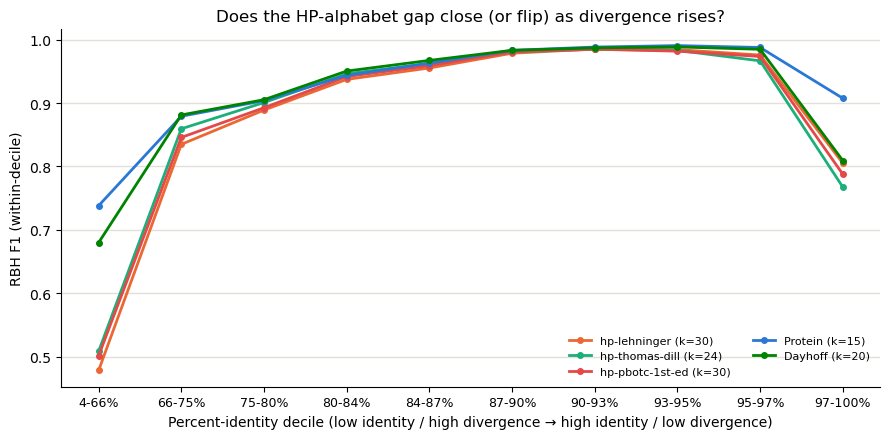

In [8]:
BLUE, GREEN, ORANGE = "#2a78d6", "#008300", "#eb6834"
# Fixed categorical order (never cycled/reassigned) — slots 2,3,4,5,7,8 of the repo's
# validated 8-hue palette (slots 1=blue, 6=green already used for protein/dayhoff above).
HP_COLORS = {
    "hp-lehninger": "#eb6834",         # orange
    "hp-thomas-dill": "#1baf7a",       # aqua
    "hp-kyte-doolittle": "#eda100",    # yellow
    "hp-thomas-dill-no-c": "#e87ba4",  # magenta
    "hp-lehninger-plus-c": "#4a3aa7",  # violet
    "hp-pbotc-1st-ed": "#e34948",      # red
}

x = np.arange(1, n_deciles + 1)
fig, ax = plt.subplots(figsize=(9, 4.5))
for enc in hp_encodings_present:
    ks = hp_ks_by_encoding[enc]
    k_label = f"k={ks[0]}" if len(ks) == 1 else f"k={ks[0]}-{ks[-1]} (median)"
    ax.plot(x, hp_decile_f1_by_encoding[enc], color=HP_COLORS[enc], lw=2, marker="o", ms=4,
            label=f"{enc} ({k_label})")
ax.plot(x, protein_decile_f1, color=BLUE, lw=2, marker="o", ms=4, label=f"Protein (k={BEST_PROTEIN_K})")
ax.plot(x, dayhoff_decile_f1, color=GREEN, lw=2, marker="o", ms=4, label=f"Dayhoff (k={BEST_DAYHOFF_K})")

ax.set_xticks(x)
ax.set_xticklabels([f"{lo:.0f}-{hi:.0f}%" for lo, hi in zip(decile_ranges["lo"], decile_ranges["hi"])], fontsize=9)
ax.set_xlabel("Percent-identity decile (low identity / high divergence → high identity / low divergence)")
ax.set_ylabel("RBH F1 (within-decile)")
ax.set_title("Does the HP-alphabet gap close (or flip) as divergence rises?")
ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="lower right", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_decile_plot.png", dpi=150)
plt.show()


**Numbers behind the decile plot, and the gap in isolation.** The figure above shows raw F1 per encoding; the table below gives the exact per-decile values, and the figure after it isolates &Delta;F1 = HP-median &minus; protein/dayhoff &mdash; the specific quantity the mechanism predicts should move away from zero (toward HP) as identity drops. Still subject to the partial-sweep caveat printed above &mdash; not every new HP variant has genome-wide k coverage cached yet, so treat this as an early look, not the final trend.

In [9]:
decile_table = pl.DataFrame({
    "decile": list(range(1, n_deciles + 1)),
    "pct_id_lo": decile_ranges["lo"].to_list(),
    "pct_id_hi": decile_ranges["hi"].to_list(),
    "n_genes": decile_ranges["n"].to_list(),
    "protein_f1": protein_decile_f1,
    "dayhoff_f1": dayhoff_decile_f1,
    **{f"{enc}_f1": hp_decile_f1_by_encoding[enc] for enc in hp_encodings_present},
})
hp_median_decile_f1 = (
    np.median([hp_decile_f1_by_encoding[enc] for enc in hp_encodings_present], axis=0)
    if hp_encodings_present else np.full(n_deciles, np.nan)
)
decile_table = decile_table.with_columns([
    pl.Series("hp_median_f1", hp_median_decile_f1),
    pl.Series("gap_vs_protein", hp_median_decile_f1 - np.array(protein_decile_f1)),
    pl.Series("gap_vs_dayhoff", hp_median_decile_f1 - np.array(dayhoff_decile_f1)),
])
print(f"Decile F1 table ({len(hp_encodings_present)}/{len(NEW_HP_ENCODINGS)} new HP variants cached — "
      f"{'COMPLETE' if len(hp_encodings_present) == len(NEW_HP_ENCODINGS) else 'PARTIAL, see section 1'})")
decile_table


Decile F1 table (3/6 new HP variants cached — PARTIAL, see section 1)


decile,pct_id_lo,pct_id_hi,n_genes,protein_f1,dayhoff_f1,hp-lehninger_f1,hp-thomas-dill_f1,hp-pbotc-1st-ed_f1,hp_median_f1,gap_vs_protein,gap_vs_dayhoff
i64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64
1,3.77734,66.4671,1671,0.73823,0.680012,0.478753,0.508792,0.50179,0.50179,-0.236439,-0.178222
2,66.4804,74.6269,1671,0.879128,0.881185,0.834882,0.859375,0.845765,0.845765,-0.033362,-0.03542
3,74.6269,79.9114,1672,0.90366,0.90519,0.888889,0.900746,0.892514,0.892514,-0.011146,-0.012676
4,79.9213,83.6697,1671,0.943611,0.950283,0.937181,0.94593,0.941634,0.941634,-0.001977,-0.008649
5,83.6703,87.0445,1672,0.962787,0.967072,0.955144,0.962236,0.958831,0.958831,-0.003956,-0.008242
6,87.0445,89.9417,1671,0.98296,0.982949,0.978417,0.980568,0.980804,0.980568,-0.002392,-0.002381
7,89.9417,92.6923,1671,0.988095,0.986889,0.985048,0.984496,0.984753,0.984753,-0.003342,-0.002136
8,92.6941,95.1362,1672,0.990436,0.988306,0.984079,0.982888,0.98161,0.982888,-0.007548,-0.005418
9,95.1389,97.4771,1671,0.987455,0.984587,0.975492,0.966394,0.973301,0.973301,-0.014154,-0.011287


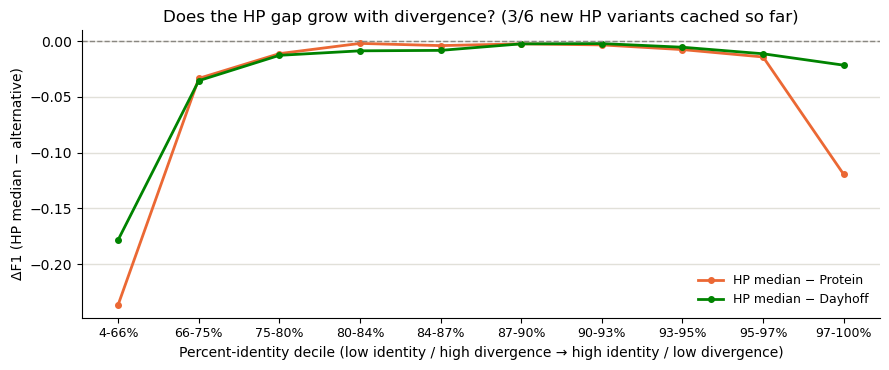

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(x, decile_table["gap_vs_protein"], color=ORANGE, lw=2, marker="o", ms=4, label="HP median − Protein")
ax.plot(x, decile_table["gap_vs_dayhoff"], color=GREEN, lw=2, marker="o", ms=4, label="HP median − Dayhoff")
ax.axhline(0, color="#898781", lw=1, ls="--")
ax.set_xticks(x)
ax.set_xticklabels([f"{lo:.0f}-{hi:.0f}%" for lo, hi in zip(decile_ranges["lo"], decile_ranges["hi"])], fontsize=9)
ax.set_xlabel("Percent-identity decile (low identity / high divergence → high identity / low divergence)")
ax.set_ylabel("ΔF1 (HP median − alternative)")
ax.set_title(f"Does the HP gap grow with divergence? ({len(hp_encodings_present)}/{len(NEW_HP_ENCODINGS)} new HP variants cached so far)")
ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="best", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_decile_gap.png", dpi=150)
plt.show()


## 4. Family deep dives (illustrative anchors, not the evidence)

Family membership sources, each real and independently verifiable (no hand-picked lists except where explicitly noted):
- **Olfactory receptors** and **CYP2/CYP3** — HGNC `gene_group` membership (`genes_in_group`), restricted to protein-coding loci.
- **Antiviral restriction factors** — a named literature list (TRIM5, SAMHD1, BST2, MX1/MX2, ZC3HAV1, APOBEC3 paralogs, IFIT/IFITM paralogs), verified against current HGNC symbols (APOBEC3E doesn't exist under current nomenclature and is excluded).
- **Sperm/testis-specific** — Kopania et al. 2022 (*MBE*) Table S12, `Testis_Specific == 'yes'`, mapped mouse ENSMUSG → human ortholog via MGI. Its control group (`Expressed_{Early,Late} == 'yes' & Testis_Specific == 'no'`) comes from the same real table, not a fabricated "other tissues" list.
- **MHC class I/II** — recap of `ou.MHC_CLASSES` (shared by notebooks 210-215) and cached results, not re-run here.

**n floor stated before looking at any result below: require n≥15 scored pairs to report a family's AUC at all.** Bootstrap 95% CIs (`bootstrap_auc_ci`) are reported for every family so small n isn't mistaken for precision.

For tractability, the HP side of the family comparison uses all 6 variants **at k=30** (each variant's smallest, most memory-tractable file, still within the full k18-30 range explored genome-wide in section 3) rather than every k — a deliberate scope reduction for this section only, stated here rather than silently. Protein (k=15) and dayhoff (k=20) remain their established best-k.

**Runtime note:** the scoring cell below is the second heavy step in this notebook, alongside section 1's sweep — the broadly-expressed "control" family alone touches ~9,300 candidate genes per file, and a couple of the k=30 HP-variant files are still 500MB-1GB+. It loops **combo-outer, family-inner** via `u.load_families_kmerseek_scores`, which scans each (encoding, ksize) raw file exactly **once** (filtered to the union of all 5 families' genes, then split back out in memory) — 9 raw scans total, not 45 (an earlier version called the single-family loader once per family per combo and rescanned the same multi-GB file up to 5x for combos shared across families). It's also checkpointed to `206_family_auc_results.csv` after every combo, so it's **safe to interrupt and re-run**: anything already in that CSV is skipped, not recomputed.

In [11]:
import openpyxl

# --- Olfactory receptors & CYP2/CYP3: real HGNC gene groups ---
or_genes = set(u.genes_in_group(hgnc, "Olfactory receptor")
               .filter(pl.col("locus_type") == "gene with protein product")["symbol"].to_list())
cyp2_genes = set(u.genes_in_group(hgnc, "Cytochrome P450 family 2")
                  .filter(pl.col("locus_type") == "gene with protein product")["symbol"].to_list())
cyp3_genes = set(u.genes_in_group(hgnc, "Cytochrome P450 family 3")
                  .filter(pl.col("locus_type") == "gene with protein product")["symbol"].to_list())
cyp23_genes = cyp2_genes | cyp3_genes

# --- Antiviral restriction factors: named list, verified against current HGNC symbols ---
antiviral_candidates = [
    "TRIM5", "SAMHD1", "BST2", "MX1", "MX2", "ZC3HAV1",
    "APOBEC3A", "APOBEC3B", "APOBEC3C", "APOBEC3D", "APOBEC3E", "APOBEC3F", "APOBEC3G", "APOBEC3H",
    "IFIT1", "IFIT2", "IFIT3", "IFIT5",
    "IFITM1", "IFITM2", "IFITM3", "IFITM5",
]
hgnc_symbols = set(hgnc["symbol"].to_list())
antiviral_genes = {g for g in antiviral_candidates if g in hgnc_symbols}
antiviral_missing = [g for g in antiviral_candidates if g not in hgnc_symbols]

# --- Sperm/testis-specific: Kopania et al. 2022 Table S12 (real data, not curated) ---
KOPANIA_XLSX = DATA_DIR / "206_kopania_ST12_gene_expression_categories.xlsx"
wb = openpyxl.load_workbook(str(KOPANIA_XLSX), read_only=True, data_only=True)
ws = wb["Sheet1"]
rows = list(ws.iter_rows(min_row=2, values_only=True))
header = list(rows[0])
header[0] = "ensmusg"
n_cols = len(header) - (1 if header[-1] is None else 0)
header = header[:n_cols]
kopania = pl.DataFrame([r[:n_cols] for r in rows[1:] if r[0] is not None], schema=header, orient="row")

testis_ensmusg = set(kopania.filter(pl.col("Testis_Specific") == "yes")["ensmusg"].to_list())
control_ensmusg = set(kopania.filter(
    ((pl.col("Expressed_Early") == "yes") | (pl.col("Expressed_Late") == "yes"))
    & (pl.col("Testis_Specific") == "no")
)["ensmusg"].to_list())

# ENSMUSG -> mouse gene symbol, from a genome-wide file's target_name (same trick as ENSG above)
mouse_targets = u.scan_genome_wide_results("protein", 15, columns=["target_name"]).unique().collect()["target_name"]
mouse_ids = u.extract_ids(mouse_targets)
ensmusg_to_symbol = dict(zip(mouse_ids["gene_id"].to_list(), mouse_ids["gene_name"].str.to_uppercase().to_list()))

testis_mouse_symbols = {ensmusg_to_symbol[e] for e in testis_ensmusg if e in ensmusg_to_symbol}
control_mouse_symbols = {ensmusg_to_symbol[e] for e in control_ensmusg if e in ensmusg_to_symbol}
sperm_testis_genes = {mouse_to_human[s] for s in testis_mouse_symbols if s in mouse_to_human}
sperm_control_genes = {mouse_to_human[s] for s in control_mouse_symbols if s in mouse_to_human}

FAMILIES = {
    "Olfactory receptors": or_genes,
    "CYP2/CYP3": cyp23_genes,
    "Antiviral restriction factors": antiviral_genes,
    "Sperm/testis-specific (Kopania)": sperm_testis_genes,
    "Sperm/testis control (broad-expr)": sperm_control_genes,
}
for name, genes in FAMILIES.items():
    print(f"{name:36s} n={len(genes):,}")
if antiviral_missing:
    print(f"\nExcluded (not in current HGNC nomenclature): {antiviral_missing}")


Olfactory receptors                  n=419
CYP2/CYP3                            n=31
Antiviral restriction factors        n=21
Sperm/testis-specific (Kopania)      n=505
Sperm/testis control (broad-expr)    n=9,289

Excluded (not in current HGNC nomenclature): ['APOBEC3E']


In [12]:
N_FLOOR = 15
FAMILY_ALPHABETS = [("protein", BEST_PROTEIN_K), ("dayhoff", BEST_DAYHOFF_K)] + [(enc, 30) for enc in ALL_HP_ENCODINGS]

FAMILY_AUC_CSV = DATA_DIR / "206_family_auc_results.csv"

# Loop combo OUTER, family INNER via u.load_families_kmerseek_scores: scans each (encoding, ksize)
# raw file ONCE (filtered to the union of every family's genes), instead of the original
# family-outer loop, which called load_family_kmerseek_scores per (family, combo) pair and
# rescanned the SAME multi-GB file once per family sharing that combo -- 5 families x ~9 combos
# = up to 45 raw scans when only ~9 are structurally needed.
#
# Checkpointed after every combo, not just at the end, so an interrupted run doesn't lose
# already-computed combos -- re-running this cell skips anything already in FAMILY_AUC_CSV.
cached = pl.read_csv(str(FAMILY_AUC_CSV)) if FAMILY_AUC_CSV.exists() else pl.DataFrame()
done_combos = set(zip(cached["encoding"].to_list(), cached["ksize"].to_list())) if cached.height else set()
family_results = cached.to_dicts()
print(f"{len(done_combos)}/{len(FAMILY_ALPHABETS)} combos already cached")

for enc, k in FAMILY_ALPHABETS:
    if (enc, k) in done_combos:
        continue
    t0 = time.time()
    try:
        family_dfs = u.load_families_kmerseek_scores(enc, k, FAMILIES, mgi_ortholog_set=mgi_set)
    except FileNotFoundError:
        print(f"{enc:20s} k={k:<3d} MISSING genome-wide file, skipping")
        continue

    new_rows = []
    for fam_name, df in family_dfs.items():
        if df.height == 0 or "label" not in df.columns:
            continue
        y = df["label"].to_numpy()
        if len(y) < N_FLOOR or y.sum() == 0 or y.sum() == len(y):
            print(f"{fam_name:36s} {enc:20s} k={k:<3d} SKIPPED (n={len(y)}, below floor or single-class)")
            continue
        scores = df["score_bonf_neglogp_cont"].fill_null(0.0).fill_nan(0.0).to_numpy()
        res = u.bootstrap_auc_ci(y, scores, n_boot=1000)
        new_rows.append({"family": fam_name, "encoding": enc, "ksize": k, "n": len(y),
                          "auc": res["point"], "auc_lo": res["lo"], "auc_hi": res["hi"]})
        print(f"{fam_name:36s} {enc:20s} k={k:<3d} n={len(y):<5d} "
              f"AUC={res['point']:.3f} [{res['lo']:.3f},{res['hi']:.3f}]")

    family_results.extend(new_rows)
    pl.DataFrame(family_results).write_csv(str(FAMILY_AUC_CSV))  # checkpoint every combo
    print(f"  -- {enc} k={k}: {len(new_rows)}/{len(FAMILIES)} families scored  ({time.time()-t0:.1f}s)", flush=True)

family_results_df = pl.DataFrame(family_results)
family_results_df


9/9 combos already cached


family,encoding,ksize,n,auc,auc_lo,auc_hi
str,str,i64,i64,f64,f64,f64
"""Olfactory receptors""","""protein""",15,14739,0.938182,0.932452,0.943641
"""CYP2/CYP3""","""protein""",15,363,0.806784,0.759369,0.854657
"""Antiviral restriction factors""","""protein""",15,38,0.578261,0.38381,0.76524
"""Sperm/testis-specific (Kopania…","""protein""",15,14466,0.979642,0.977333,0.982063
"""Sperm/testis control (broad-ex…","""protein""",15,226869,0.980618,0.980109,0.981096
…,…,…,…,…,…,…
"""Olfactory receptors""","""hp-pbotc-1st-ed""",30,43010,0.957224,0.95254,0.961525
"""CYP2/CYP3""","""hp-pbotc-1st-ed""",30,896,0.811314,0.783836,0.836739
"""Antiviral restriction factors""","""hp-pbotc-1st-ed""",30,134,0.934705,0.884002,0.9724


In [13]:
# Readable family × encoding AUC table, plus HP median/range and the HP-minus-protein/dayhoff
# gap — feeds directly into the forest plot below, but as exact numbers rather than eyeballed
# error bars.
family_pivot = family_results_df.pivot(values="auc", index="family", on="encoding")
print("Per-family AUC by encoding (feeds the forest plot below):")
print(family_pivot)

hp_summary = (
    family_results_df.filter(pl.col("encoding").is_in(ALL_HP_ENCODINGS))
    .group_by("family")
    .agg([pl.col("auc").median().alias("hp_median_auc"),
          pl.col("auc").min().alias("hp_min_auc"),
          pl.col("auc").max().alias("hp_max_auc")])
)
family_gap_table = (
    hp_summary
    .join(family_results_df.filter(pl.col("encoding") == "protein").select("family", pl.col("auc").alias("protein_auc")), on="family")
    .join(family_results_df.filter(pl.col("encoding") == "dayhoff").select("family", pl.col("auc").alias("dayhoff_auc")), on="family")
    .with_columns([
        (pl.col("hp_median_auc") - pl.col("protein_auc")).alias("hp_minus_protein"),
        (pl.col("hp_median_auc") - pl.col("dayhoff_auc")).alias("hp_minus_dayhoff"),
    ])
    .sort("hp_minus_protein", descending=True)
)
print("\nHP-vs-baseline gap, ranked largest HP advantage first:")
family_gap_table


Per-family AUC by encoding (feeds the forest plot below):
shape: (5, 10)
┌────────────┬──────────┬──────────┬──────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ family     ┆ protein  ┆ dayhoff  ┆ hp       ┆ … ┆ hp-kyte-do ┆ hp-thomas ┆ hp-lehnin ┆ hp-pbotc- │
│ ---        ┆ ---      ┆ ---      ┆ ---      ┆   ┆ olittle    ┆ -dill-no- ┆ ger-plus- ┆ 1st-ed    │
│ str        ┆ f64      ┆ f64      ┆ f64      ┆   ┆ ---        ┆ c         ┆ c         ┆ ---       │
│            ┆          ┆          ┆          ┆   ┆ f64        ┆ ---       ┆ ---       ┆ f64       │
│            ┆          ┆          ┆          ┆   ┆            ┆ f64       ┆ f64       ┆           │
╞════════════╪══════════╪══════════╪══════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ Olfactory  ┆ 0.938182 ┆ 0.970373 ┆ 0.954121 ┆ … ┆ 0.956232   ┆ 0.96557   ┆ 0.9516    ┆ 0.957224  │
│ receptors  ┆          ┆          ┆          ┆   ┆            ┆           ┆           ┆           │
│ CYP2/CYP3  ┆ 0.8

family,hp_median_auc,hp_min_auc,hp_max_auc,protein_auc,dayhoff_auc,hp_minus_protein,hp_minus_dayhoff
str,f64,f64,f64,f64,f64,f64,f64
"""Antiviral restriction factors""",0.934705,0.907768,0.956457,0.578261,0.567568,0.356444,0.367137
"""CYP2/CYP3""",0.867911,0.811314,0.886578,0.806784,0.912842,0.061127,-0.044931
"""Olfactory receptors""",0.956232,0.9516,0.96557,0.938182,0.970373,0.01805,-0.014141
"""Sperm/testis control (broad-ex…",0.997111,0.996586,0.997742,0.980618,0.997753,0.016493,-0.000642
"""Sperm/testis-specific (Kopania…",0.988914,0.986254,0.991634,0.979642,0.994264,0.009272,-0.00535


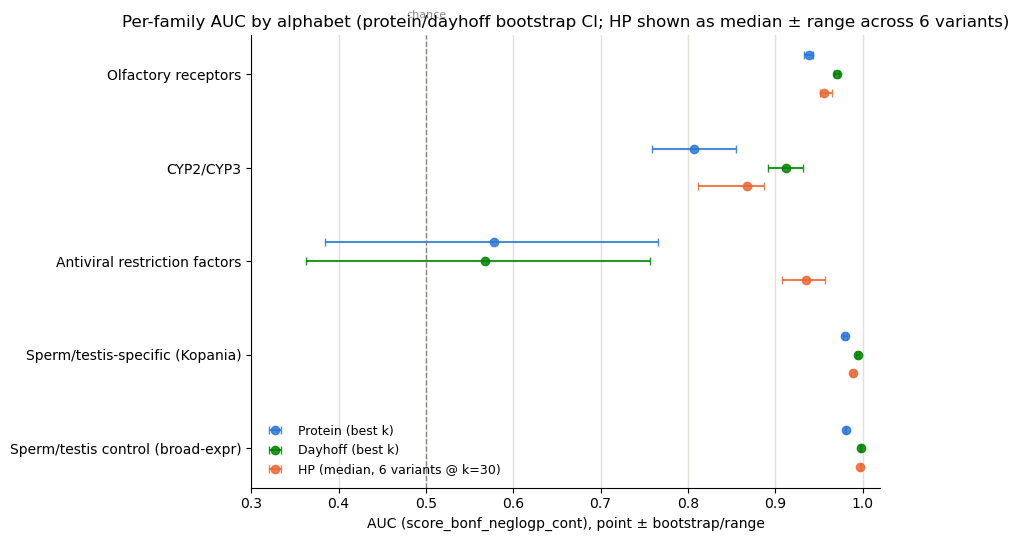

In [14]:
# Collapse the 6 HP variants to a median+range per family (same envelope idea as section 3)
hp_family = (
    family_results_df.filter(pl.col("encoding").is_in(ALL_HP_ENCODINGS))
    .group_by("family")
    .agg([pl.col("auc").median().alias("auc"), pl.col("auc").min().alias("auc_lo"),
          pl.col("auc").max().alias("auc_hi"), pl.col("n").min().alias("n")])
    .with_columns(pl.lit("HP (median, 6 variants @ k=30)").alias("encoding"))
)
protein_family = family_results_df.filter(pl.col("encoding") == "protein")
dayhoff_family = family_results_df.filter(pl.col("encoding") == "dayhoff")

fam_order = list(FAMILIES.keys())
fig, ax = plt.subplots(figsize=(9, 0.9 * len(fam_order) + 1))
for i, fam in enumerate(fam_order):
    y0 = len(fam_order) - i
    for src, color, dy, label in [
        (protein_family, BLUE, 0.20, "Protein (best k)"),
        (dayhoff_family, GREEN, 0.0, "Dayhoff (best k)"),
        (hp_family, ORANGE, -0.20, "HP (median, 6 variants @ k=30)"),
    ]:
        row = src.filter(pl.col("family") == fam)
        if row.height == 0:
            continue
        auc, lo, hi, n = row["auc"][0], row["auc_lo"][0], row["auc_hi"][0], row["n"][0]
        ax.errorbar(auc, y0 + dy, xerr=[[auc - lo], [hi - auc]], fmt="o", color=color,
                    ms=6, elinewidth=1.5, capsize=3, alpha=0.85,
                    label=label if i == 0 else None)

ax.set_yticks(range(1, len(fam_order) + 1))
ax.set_yticklabels(list(reversed(fam_order)), fontsize=10)
ax.set_xlim(0.3, 1.02)
ax.set_xlabel("AUC (score_bonf_neglogp_cont), point ± bootstrap/range")
ax.axvline(0.5, color="#898781", lw=1, ls="--")
ax.text(0.5, len(fam_order) + 0.6, "chance", ha="center", fontsize=8, color="#898781")
ax.grid(axis="x", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="lower left", fontsize=9)
ax.set_title("Per-family AUC by alphabet (protein/dayhoff bootstrap CI; HP shown as median ± range across 6 variants)")
fig.tight_layout()
fig.savefig(OUT_DIR / "206_family_auc.png", dpi=150)
plt.show()


### MHC class I/II recap

Not re-run — reuses notebook 210's cached search results (`210_human_mhc_vs_mouse.*.csv`, MHC-gene-restricted searches already on disk) and its `MHC_CLASSES` taxonomy, scored here with the same `score_bonf_neglogp_cont` composite as the rest of this notebook (201 originally used raw containment) so the MHC numbers are directly comparable to the family table above.

In [15]:
# MHC taxonomy from the shared module (ou.MHC_CLASSES), not a verbatim copy: this dict used
# to be duplicated here from notebook 201, which meant a correction had to be made twice.
MHC_CLASSES = u.MHC_CLASSES

def load_mhc_cached(csv_path, mgi_set_):
    df = pl.read_csv(str(csv_path))
    df = df.with_columns([
        pl.col("query_name").str.split("|").list.get(6).str.to_uppercase().alias("human_gene"),
        pl.col("target_name").str.split("|").list.get(6).str.to_uppercase().alias("mouse_gene"),
    ])
    n_total = u.N_PROTEINS["human"] * u.N_PROTEINS["mouse"]
    poisson_p = df["poisson_pvalue"].fill_null(1.0).to_numpy()
    df = df.with_columns([
        pl.Series("poisson_p_bonf_conservative", np.clip(poisson_p * n_total, 0, 1)),
        pl.Series("poisson_p_bh_conservative", u.bh_conservative(poisson_p, n_total)),
    ])
    df = u.add_composite_scores(df)
    label = [int((h, m) in mgi_set_) for h, m in zip(df["human_gene"].to_list(), df["mouse_gene"].to_list())]
    df = df.with_columns(pl.Series("label", label, dtype=pl.Int8))
    df = df.with_columns(pl.col("human_gene").replace_strict(MHC_CLASSES, default="other").alias("mhc_class"))
    return df

MHC_CACHE_FILES = {
    "protein_k15": "210_human_mhc_vs_mouse.protein_k15.csv",
    "dayhoff_k20": "210_human_mhc_vs_mouse.dayhoff_k20.csv",
    "hp_k30": "210_human_mhc_vs_mouse.hp_k30.csv",
    "hp_lehninger_k30": "210_human_mhc_vs_mouse.hp_lehninger_k30.csv",
    "hp_thomas_dill_k26": "210_human_mhc_vs_mouse.hp_thomas_dill_k26.csv",
    # hp_pbotc_1st_ed at k=19 -- notebook 211's single best class I combo (ROC-AUC 0.990 under
    # the syntenically-nearest label policy). Included here because the other HP entries sit at
    # k=26-30, the high-k end, and this notebook's argument is about the divergence response:
    # without a low-k HP point the MHC recap can only show one side of that curve. k=19 is the
    # lowest k with a genome-wide result for this alphabet -- k=18 ran but its results parquet
    # was never written, and nothing below 18 has been searched for any HP variant.
    "hp_pbotc_1st_ed_k19": "210_human_mhc_vs_mouse.hp_pbotc_1st_ed_k19.csv",
}

mhc_results = []
for label, fname in MHC_CACHE_FILES.items():
    fpath = DATA_DIR / fname
    if not fpath.exists():
        continue
    df = load_mhc_cached(fpath, mgi_set)
    groups = {
        "ALL MHC": df,
        "class I (classical+non-classical)": df.filter(pl.col("mhc_class").str.starts_with("I ") & ~pl.col("mhc_class").str.contains("MIC")),
        "class II (alpha+beta)": df.filter(pl.col("mhc_class").str.starts_with("II")),
    }
    for group_name, sub in groups.items():
        y = sub["label"].to_numpy()
        if len(y) < N_FLOOR or y.sum() == 0 or y.sum() == len(y):
            continue
        scores = sub["score_bonf_neglogp_cont"].fill_null(0.0).fill_nan(0.0).to_numpy()
        res = u.bootstrap_auc_ci(y, scores, n_boot=1000)
        mhc_results.append({"combo": label, "group": group_name, "n": len(y),
                             "auc": res["point"], "auc_lo": res["lo"], "auc_hi": res["hi"]})
        print(f"{label:20s} {group_name:36s} n={len(y):<4d} AUC={res['point']:.3f} [{res['lo']:.3f},{res['hi']:.3f}]")

mhc_results_df = pl.DataFrame(mhc_results)


protein_k15          ALL MHC                              n=162  AUC=0.457 [0.367,0.543]
protein_k15          class I (classical+non-classical)    n=132  AUC=0.286 [0.201,0.371]
protein_k15          class II (alpha+beta)                n=17   AUC=0.933 [0.794,1.000]
dayhoff_k20          ALL MHC                              n=363  AUC=0.545 [0.472,0.615]
dayhoff_k20          class I (classical+non-classical)    n=185  AUC=0.555 [0.479,0.638]
dayhoff_k20          class II (alpha+beta)                n=33   AUC=1.000 [1.000,1.000]
hp_k30               ALL MHC                              n=278  AUC=0.843 [0.771,0.905]
hp_k30               class I (classical+non-classical)    n=168  AUC=0.545 [0.422,0.669]
hp_k30               class II (alpha+beta)                n=59   AUC=0.928 [0.853,0.982]
hp_lehninger_k30     ALL MHC                              n=278  AUC=0.843 [0.770,0.914]
hp_lehninger_k30     class I (classical+non-classical)    n=168  AUC=0.545 [0.434,0.662]
hp_lehninger_k30     

In [16]:
print("MHC recap table (feeds the figure below):")
mhc_results_df


MHC recap table (feeds the figure below):


combo,group,n,auc,auc_lo,auc_hi
str,str,i64,f64,f64,f64
"""protein_k15""","""ALL MHC""",162,0.45698,0.367402,0.54343
"""protein_k15""","""class I (classical+non-classic…",132,0.286223,0.200588,0.370727
"""protein_k15""","""class II (alpha+beta)""",17,0.932692,0.794129,1.0
"""dayhoff_k20""","""ALL MHC""",363,0.54542,0.471904,0.61464
"""dayhoff_k20""","""class I (classical+non-classic…",185,0.555398,0.479002,0.638317
…,…,…,…,…,…
"""hp_lehninger_k30""","""class I (classical+non-classic…",168,0.545436,0.433699,0.661588
"""hp_lehninger_k30""","""class II (alpha+beta)""",59,0.927945,0.845808,0.983197
"""hp_thomas_dill_k26""","""ALL MHC""",1774,0.866332,0.815801,0.909563


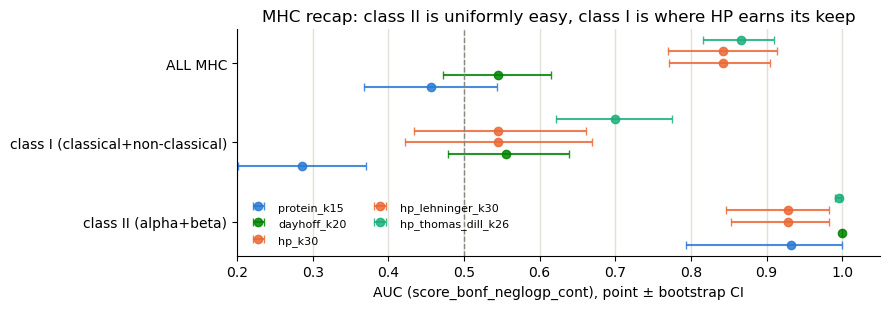

In [17]:
# MHC recap as a figure, in the same forest-plot style as the family AUC figure above, so
# the two are visually comparable rather than one being a table and the other a plot.
MHC_COMBO_COLORS = {
    "protein_k15": BLUE, "dayhoff_k20": GREEN, "hp_k30": ORANGE,
    "hp_lehninger_k30": HP_COLORS["hp-lehninger"], "hp_thomas_dill_k26": HP_COLORS["hp-thomas-dill"],
    "hp_pbotc_1st_ed_k19": HP_COLORS["hp-pbotc-1st-ed"],
}
mhc_group_order = ["ALL MHC", "class I (classical+non-classical)", "class II (alpha+beta)"]
mhc_combo_order = [c for c in MHC_CACHE_FILES if c in set(mhc_results_df["combo"].to_list())]

fig, ax = plt.subplots(figsize=(9, 3.2))
n_combo = len(mhc_combo_order)
offsets = np.linspace(-0.3, 0.3, n_combo) if n_combo > 1 else [0.0]
for combo, dy in zip(mhc_combo_order, offsets):
    for gi, group in enumerate(mhc_group_order):
        row = mhc_results_df.filter((pl.col("combo") == combo) & (pl.col("group") == group))
        if row.height == 0:
            continue
        y0 = len(mhc_group_order) - gi
        auc, lo, hi = row["auc"][0], row["auc_lo"][0], row["auc_hi"][0]
        ax.errorbar(auc, y0 + dy, xerr=[[auc - lo], [hi - auc]], fmt="o",
                     color=MHC_COMBO_COLORS.get(combo, "#898781"),
                     ms=6, elinewidth=1.5, capsize=3, alpha=0.85, label=combo if gi == 0 else None)

ax.set_yticks(range(1, len(mhc_group_order) + 1))
ax.set_yticklabels(list(reversed(mhc_group_order)), fontsize=10)
ax.set_xlim(0.2, 1.05)
ax.axvline(0.5, color="#898781", lw=1, ls="--")
ax.set_xlabel("AUC (score_bonf_neglogp_cont), point ± bootstrap CI")
ax.set_title("MHC recap: class II is uniformly easy, class I is where HP earns its keep")
ax.grid(axis="x", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="lower left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_mhc_recap.png", dpi=150)
plt.show()


## 4b. Metric choice: does jaccard/enrichment beat `score_bonf_neglogp_cont` here too?

Section 4 above scored every family and MHC group with exactly one composite, `score_bonf_neglogp_cont`, chosen because it's this repo's best-AUPRC composite on the *genome-wide* benchmark. But notebook 213 found something specific to the HP family on the harder MHC test: containment saturates near 1.0 for almost every HP-family candidate pair, so any p-value-based composite built on it collapses toward chance, and **plain jaccard** &mdash; not a composite &mdash; was the single highest-AUPRC metric in 48/54 scored HP combos there. That result was never checked against `score_bonf_neglogp_cont` specifically (201 predates this notebook's composite), and never checked at all on the family anchors (olfactory receptors, CYP2/CYP3, antiviral restriction factors, sperm/testis). This section runs the full `ou.compute_aucs` 12-metric leaderboard (`ou.SCORE_COLS`) against the same family/MHC data assembled in section 4, to check whether this notebook's headline metric is actually the best one available, or whether jaccard/enrichment do better here too.

**MHC recap (below, runs now)** reuses the already-cached `210_human_mhc_vs_mouse.*.csv` files &mdash; small, KB&ndash;MB range, `jaccard` already present as a raw kmerseek column, no rescan needed.

**Family-anchor version (further below) needs a fresh raw-file scan first.** `u.load_family(ies)_kmerseek_scores` never pulled `jaccard` out of the raw genome-wide files before now &mdash; only `enrichment`/`containment` &mdash; so section 4's cached `206_family_auc_results.csv` (a single `score_bonf_neglogp_cont` point per family/combo) can't answer this. Fixed in `ortholog_analysis_utils.py` (added `jaccard` to both loaders' `base_cols`) as part of this section; flagged as its own heavy step below, same profile as section 4's own scoring cell.


In [18]:
# Full 12-metric leaderboard (ou.SCORE_COLS) for every cached MHC combo x group, not just
# score_bonf_neglogp_cont -- reuses load_mhc_cached's already-computed add_composite_scores
# output (jaccard already present as a raw kmerseek column in these cached CSVs, no rescan).
mhc_leaderboard_rows = []
for label, fname in MHC_CACHE_FILES.items():
    fpath = DATA_DIR / fname
    if not fpath.exists():
        continue
    mdf = load_mhc_cached(fpath, mgi_set)
    groups = {
        "ALL MHC": mdf,
        "class I (classical+non-classical)": mdf.filter(pl.col("mhc_class").str.starts_with("I ") & ~pl.col("mhc_class").str.contains("MIC")),
        "class II (alpha+beta)": mdf.filter(pl.col("mhc_class").str.starts_with("II")),
    }
    for group_name, sub in groups.items():
        y = sub["label"].to_numpy()
        if len(y) < N_FLOOR or y.sum() == 0 or y.sum() == len(y):
            continue
        aucs = u.compute_aucs(sub)
        for metric, v in aucs.items():
            mhc_leaderboard_rows.append({"combo": label, "group": group_name, "metric": metric, **v})

mhc_leaderboard_df = pl.DataFrame(mhc_leaderboard_rows)
winner_per_mhc = (mhc_leaderboard_df.sort("pr_auc", descending=True)
                  .group_by(["combo", "group"], maintain_order=True).first()
                  .select(["combo", "group", "metric", "pr_auc", "roc_auc"]))
print("Winning metric (highest AUPRC), per MHC combo x group:")
print(winner_per_mhc)
print("\nWinner tally across all combo x group cells:")
print(winner_per_mhc["metric"].value_counts().sort("count", descending=True))

headline = mhc_leaderboard_df.filter(pl.col("metric") == "score_bonf_neglogp_cont").rename({"pr_auc": "headline_pr_auc", "roc_auc": "headline_roc_auc"})
jacc = mhc_leaderboard_df.filter(pl.col("metric") == "jaccard").rename({"pr_auc": "jaccard_pr_auc", "roc_auc": "jaccard_roc_auc"})
enr = mhc_leaderboard_df.filter(pl.col("metric") == "enrichment").rename({"pr_auc": "enrichment_pr_auc", "roc_auc": "enrichment_roc_auc"})
mhc_metric_compare = (
    headline.select(["combo", "group", "headline_pr_auc", "headline_roc_auc"])
    .join(jacc.select(["combo", "group", "jaccard_pr_auc", "jaccard_roc_auc"]), on=["combo", "group"])
    .join(enr.select(["combo", "group", "enrichment_pr_auc", "enrichment_roc_auc"]), on=["combo", "group"])
    .with_columns([
        (pl.col("jaccard_pr_auc") - pl.col("headline_pr_auc")).alias("jaccard_minus_headline_pr_auc"),
        (pl.col("enrichment_pr_auc") - pl.col("headline_pr_auc")).alias("enrichment_minus_headline_pr_auc"),
    ])
)
print("\nHeadline (score_bonf_neglogp_cont) vs jaccard vs enrichment, by AUPRC:")
mhc_metric_compare


Winning metric (highest AUPRC), per MHC combo x group:
shape: (15, 5)
┌────────────────────┬─────────────────────────┬─────────────────────────┬──────────┬──────────┐
│ combo              ┆ group                   ┆ metric                  ┆ pr_auc   ┆ roc_auc  │
│ ---                ┆ ---                     ┆ ---                     ┆ ---      ┆ ---      │
│ str                ┆ str                     ┆ str                     ┆ f64      ┆ f64      │
╞════════════════════╪═════════════════════════╪═════════════════════════╪══════════╪══════════╡
│ dayhoff_k20        ┆ class II (alpha+beta)   ┆ score_enr_cont          ┆ 1.0      ┆ 1.0      │
│ protein_k15        ┆ class II (alpha+beta)   ┆ jaccard                 ┆ 0.97966  ┆ 0.923077 │
│ hp_thomas_dill_k26 ┆ class II (alpha+beta)   ┆ score_tfidf_cont        ┆ 0.958409 ┆ 0.996507 │
│ hp_k30             ┆ class II (alpha+beta)   ┆ score_enr_cont_freq     ┆ 0.922374 ┆ 0.954887 │
│ hp_lehninger_k30   ┆ class II (alpha+beta)   ┆ score_en

combo,group,headline_pr_auc,headline_roc_auc,jaccard_pr_auc,jaccard_roc_auc,enrichment_pr_auc,enrichment_roc_auc,jaccard_minus_headline_pr_auc,enrichment_minus_headline_pr_auc
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""protein_k15""","""ALL MHC""",0.636952,0.45698,0.625719,0.445898,0.634072,0.448361,-0.011233,-0.00288
"""protein_k15""","""class I (classical+non-classic…",0.411005,0.286223,0.38009,0.278416,0.391652,0.283467,-0.030916,-0.019353
"""protein_k15""","""class II (alpha+beta)""",0.975983,0.932692,0.97966,0.923077,0.975983,0.913462,0.003676,0.0
"""dayhoff_k20""","""ALL MHC""",0.566681,0.54542,0.61429,0.614462,0.554026,0.495259,0.047609,-0.012655
"""dayhoff_k20""","""class I (classical+non-classic…",0.552735,0.555398,0.558097,0.541313,0.553327,0.543022,0.005361,0.000591
…,…,…,…,…,…,…,…,…,…
"""hp_lehninger_k30""","""class I (classical+non-classic…",0.127518,0.545436,0.185276,0.71176,0.159442,0.627467,0.057758,0.031924
"""hp_lehninger_k30""","""class II (alpha+beta)""",0.867552,0.927945,0.876625,0.934837,0.867552,0.927945,0.009073,0.0
"""hp_thomas_dill_k26""","""ALL MHC""",0.67171,0.866332,0.74029,0.954081,0.665465,0.899738,0.068581,-0.006245


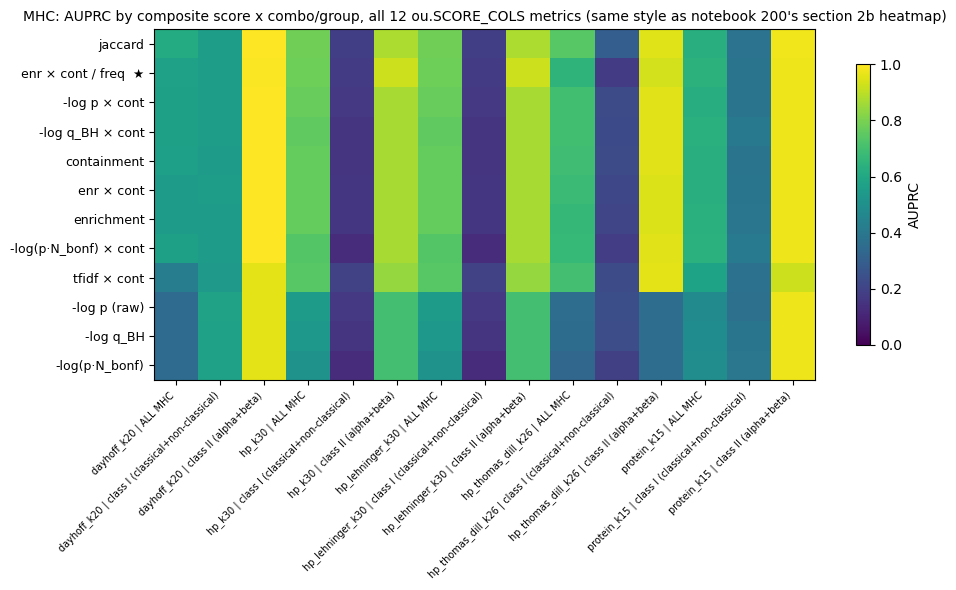

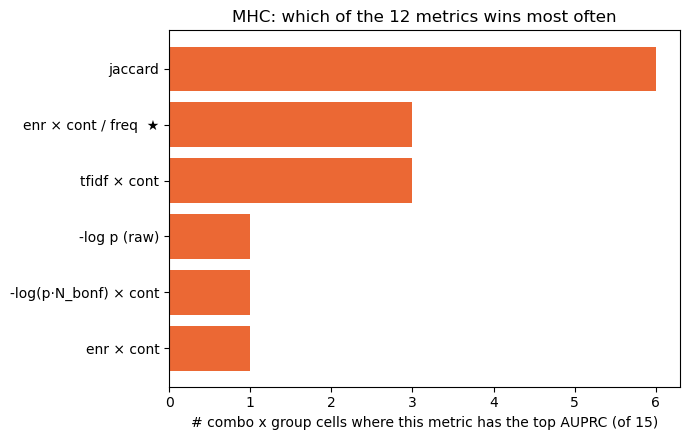

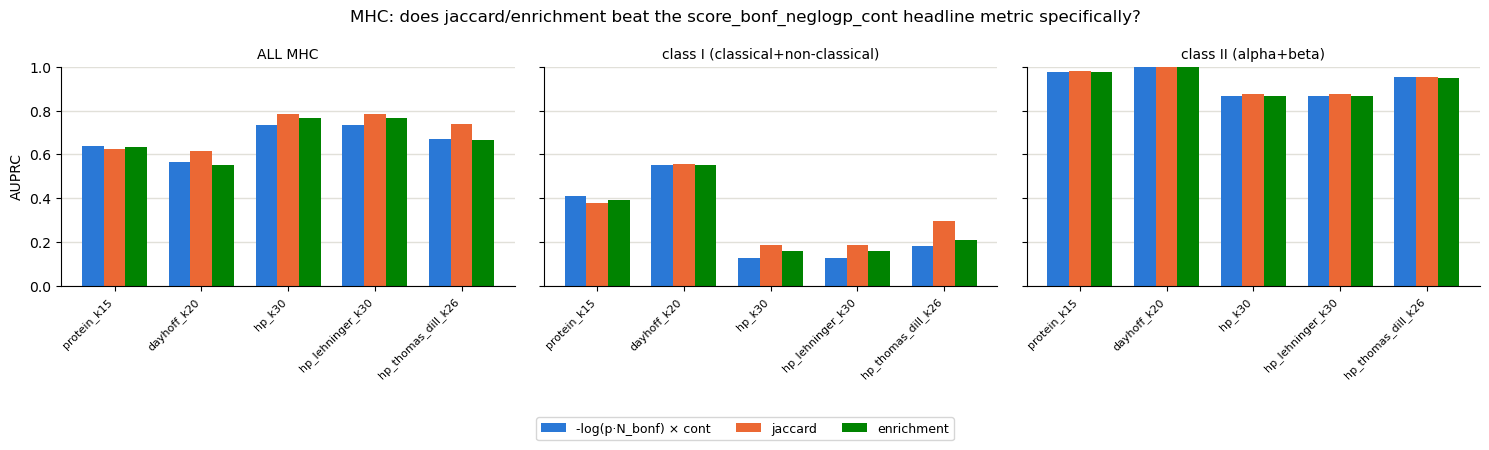

In [19]:
# Figure 1: full 12-metric heatmap (metric x combo x group), same style as notebook 200's
# section 2b heatmap -- rows ordered by mean AUPRC, not just the 3 metrics singled out below.
mhc_leaderboard_df = mhc_leaderboard_df.with_columns(
    (pl.col("combo") + " | " + pl.col("group")).alias("cell")
)
cell_order = (mhc_leaderboard_df.select(["combo", "group", "cell"]).unique()
              .join(pl.DataFrame({"combo": mhc_combo_order_4b if "mhc_combo_order_4b" in dir() else
                                   [c for c in MHC_CACHE_FILES if c in set(mhc_leaderboard_df["combo"].to_list())]}),
                     on="combo", how="inner")
              .sort(["combo", "group"])["cell"].to_list())
metric_order_mhc = (mhc_leaderboard_df.group_by("metric").agg(pl.col("pr_auc").mean().alias("mean_pr_auc"))
                     .sort("mean_pr_auc", descending=True)["metric"].to_list())
pivot_mhc = (mhc_leaderboard_df.pivot(index="metric", on="cell", values="pr_auc")
             .to_pandas().set_index("metric").reindex(index=metric_order_mhc, columns=cell_order))

fig, ax = plt.subplots(figsize=(max(10, 0.5 * len(cell_order)), 6))
im = ax.imshow(pivot_mhc.to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(metric_order_mhc)))
ax.set_yticklabels([u.SCORE_LABELS.get(m, m) for m in metric_order_mhc], fontsize=9)
ax.set_xticks(range(len(cell_order)))
ax.set_xticklabels(cell_order, rotation=45, ha="right", fontsize=7)
ax.set_title(f"MHC: AUPRC by composite score x combo/group, all {len(u.SCORE_COLS)} ou.SCORE_COLS metrics "
             "(same style as notebook 200's section 2b heatmap)", fontsize=10)
fig.colorbar(im, ax=ax, label="AUPRC", shrink=0.8)
plt.tight_layout()
fig.savefig(OUT_DIR / "206_mhc_metric_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure 2: win-counts across all 12 metrics (not just headline/jaccard/enrichment) -- same
# style as notebook 200's win-count bar chart.
win_counts_mhc = (winner_per_mhc.group_by("metric").agg(pl.len().alias("n_wins"))
                   .sort("n_wins", descending=True))
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh([u.SCORE_LABELS.get(m, m) for m in win_counts_mhc["metric"].to_list()][::-1],
        win_counts_mhc["n_wins"].to_list()[::-1], color=ORANGE)
ax.set_xlabel(f"# combo x group cells where this metric has the top AUPRC (of {winner_per_mhc.height})")
ax.set_title("MHC: which of the 12 metrics wins most often")
plt.tight_layout()
fig.savefig(OUT_DIR / "206_mhc_metric_win_counts.png", dpi=150, bbox_inches="tight")
plt.show()

# Figure 3: headline vs jaccard vs enrichment specifically (the three this section's verdict
# discusses in detail) -- kept as its own grouped-bar figure since the heatmap above makes
# these three hard to compare directly across combos at a glance.
mhc_combo_order_4b = [c for c in MHC_CACHE_FILES if c in set(mhc_leaderboard_df["combo"].to_list())]
KEY_METRICS_4B = ["score_bonf_neglogp_cont", "jaccard", "enrichment"]
METRIC_COLORS_4B = {"score_bonf_neglogp_cont": BLUE, "jaccard": ORANGE, "enrichment": GREEN}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, group in zip(axes, mhc_group_order):
    x = np.arange(len(mhc_combo_order_4b))
    width = 0.25
    for i, metric in enumerate(KEY_METRICS_4B):
        vals = []
        for combo in mhc_combo_order_4b:
            row = mhc_leaderboard_df.filter(
                (pl.col("combo") == combo) & (pl.col("group") == group) & (pl.col("metric") == metric)
            )
            vals.append(row["pr_auc"][0] if row.height else np.nan)
        ax.bar(x + (i - 1) * width, vals, width, color=METRIC_COLORS_4B[metric],
               label=u.SCORE_LABELS.get(metric, metric) if ax is axes[0] else None)
    ax.set_xticks(x)
    ax.set_xticklabels(mhc_combo_order_4b, rotation=45, ha="right", fontsize=8)
    ax.set_title(group, fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel("AUPRC")
fig.legend(loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("MHC: does jaccard/enrichment beat the score_bonf_neglogp_cont headline metric specifically?", fontsize=12)
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(OUT_DIR / "206_mhc_metric_leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()


**Family-anchor metric leaderboard &mdash; heavy step, run yourself.** Same profile as section 4's own scoring cell: up to ~1GB per HP-variant k=30 file, 8 combos (`FAMILY_ALPHABETS`) x 5 families, one raw scan per combo via the now-jaccard-including `u.load_families_kmerseek_scores`. Checkpointed to `206_family_metric_leaderboard.csv` after every combo &mdash; safe to interrupt and re-run, anything already in that CSV is skipped rather than recomputed. **Run this cell yourself and watch it.**


In [20]:
FAMILY_METRIC_CSV = DATA_DIR / "206_family_metric_leaderboard.csv"

cached_ml = pl.read_csv(str(FAMILY_METRIC_CSV)) if FAMILY_METRIC_CSV.exists() else pl.DataFrame()
done_ml_combos = set(zip(cached_ml["encoding"].to_list(), cached_ml["ksize"].to_list())) if cached_ml.height else set()
family_metric_rows = cached_ml.to_dicts()
print(f"{len(done_ml_combos)}/{len(FAMILY_ALPHABETS)} combos already cached")

for enc, k in FAMILY_ALPHABETS:
    if (enc, k) in done_ml_combos:
        continue
    t0 = time.time()
    try:
        family_dfs = u.load_families_kmerseek_scores(enc, k, FAMILIES, mgi_ortholog_set=mgi_set)
    except FileNotFoundError:
        print(f"{enc:20s} k={k:<3d} MISSING genome-wide file, skipping")
        continue

    new_rows = []
    for fam_name, fdf in family_dfs.items():
        if fdf.height == 0 or "label" not in fdf.columns:
            continue
        y = fdf["label"].to_numpy()
        if len(y) < N_FLOOR or y.sum() == 0 or y.sum() == len(y):
            print(f"{fam_name:36s} {enc:20s} k={k:<3d} SKIPPED (n={len(y)}, below floor or single-class)")
            continue
        aucs = u.compute_aucs(fdf)
        for metric, v in aucs.items():
            new_rows.append({"family": fam_name, "encoding": enc, "ksize": k, "n": len(y),
                              "metric": metric, **v})

    winner = max(new_rows, key=lambda r: r["pr_auc"])["metric"] if new_rows else None
    n_fam_scored = len({r["family"] for r in new_rows})
    print(f"{enc:20s} k={k:<3d} {n_fam_scored}/{len(FAMILIES)} families scored, "
          f"top metric this combo: {winner}  ({time.time()-t0:.1f}s)")

    family_metric_rows.extend(new_rows)
    pl.DataFrame(family_metric_rows).write_csv(str(FAMILY_METRIC_CSV))  # checkpoint every combo

family_metric_df = pl.DataFrame(family_metric_rows)
family_metric_df


9/9 combos already cached


family,encoding,ksize,n,metric,roc_auc,pr_auc
str,str,i64,i64,str,f64,f64
"""Olfactory receptors""","""protein""",15,14739,"""score_enr_cont_freq""",0.952611,0.84079
"""Olfactory receptors""","""protein""",15,14739,"""score_enr_cont""",0.949412,0.831706
"""Olfactory receptors""","""protein""",15,14739,"""score_neglogp_cont""",0.94573,0.819516
"""Olfactory receptors""","""protein""",15,14739,"""score_tfidf_cont""",0.903763,0.739839
"""Olfactory receptors""","""protein""",15,14739,"""score_neglogp""",0.894666,0.524465
…,…,…,…,…,…,…
"""Sperm/testis control (broad-ex…","""hp-pbotc-1st-ed""",30,9967168,"""score_bh_neglogq""",0.822207,0.039168
"""Sperm/testis control (broad-ex…","""hp-pbotc-1st-ed""",30,9967168,"""score_bh_neglogq_cont""",0.996649,0.957171
"""Sperm/testis control (broad-ex…","""hp-pbotc-1st-ed""",30,9967168,"""enrichment""",0.999162,0.959041


9/9 combos scored so far -- COMPLETE

Winning metric (highest AUPRC) tally, family x combo, all 12 ou.SCORE_COLS metrics:
shape: (6, 2)
┌─────────────────────┬───────┐
│ metric              ┆ count │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ score_enr_cont_freq ┆ 19    │
│ score_enr_cont      ┆ 13    │
│ enrichment          ┆ 5     │
│ score_tfidf_cont    ┆ 4     │
│ jaccard             ┆ 2     │
│ score_neglogp       ┆ 2     │
└─────────────────────┴───────┘

Mean AUPRC gap (jaccard - headline): 0.001
Mean AUPRC gap (enrichment - headline): 0.035


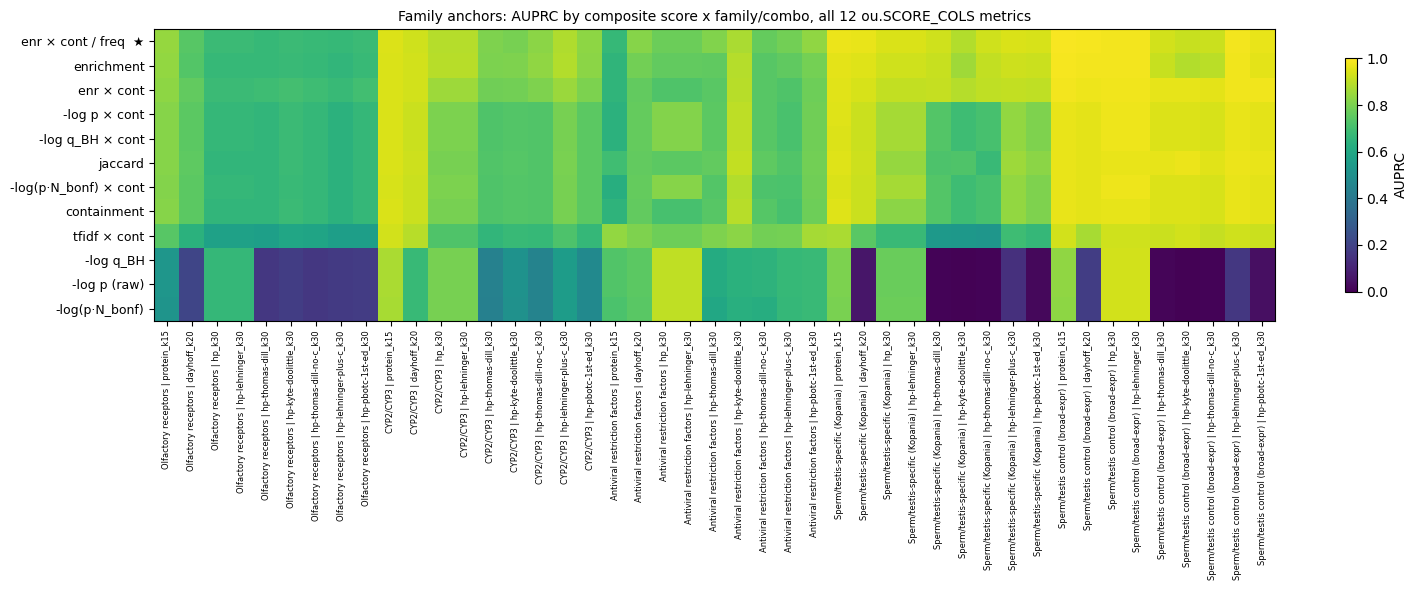

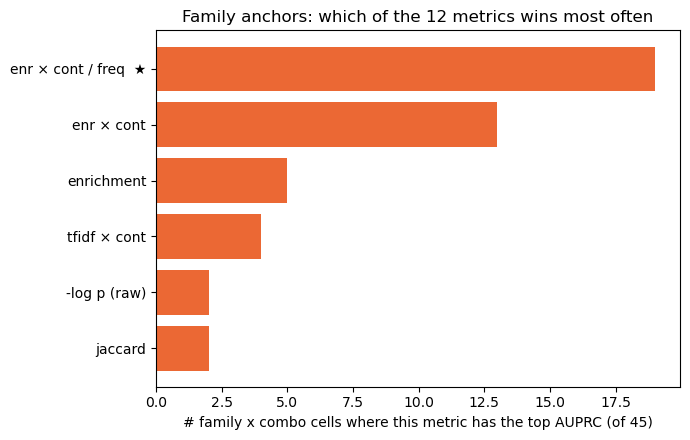

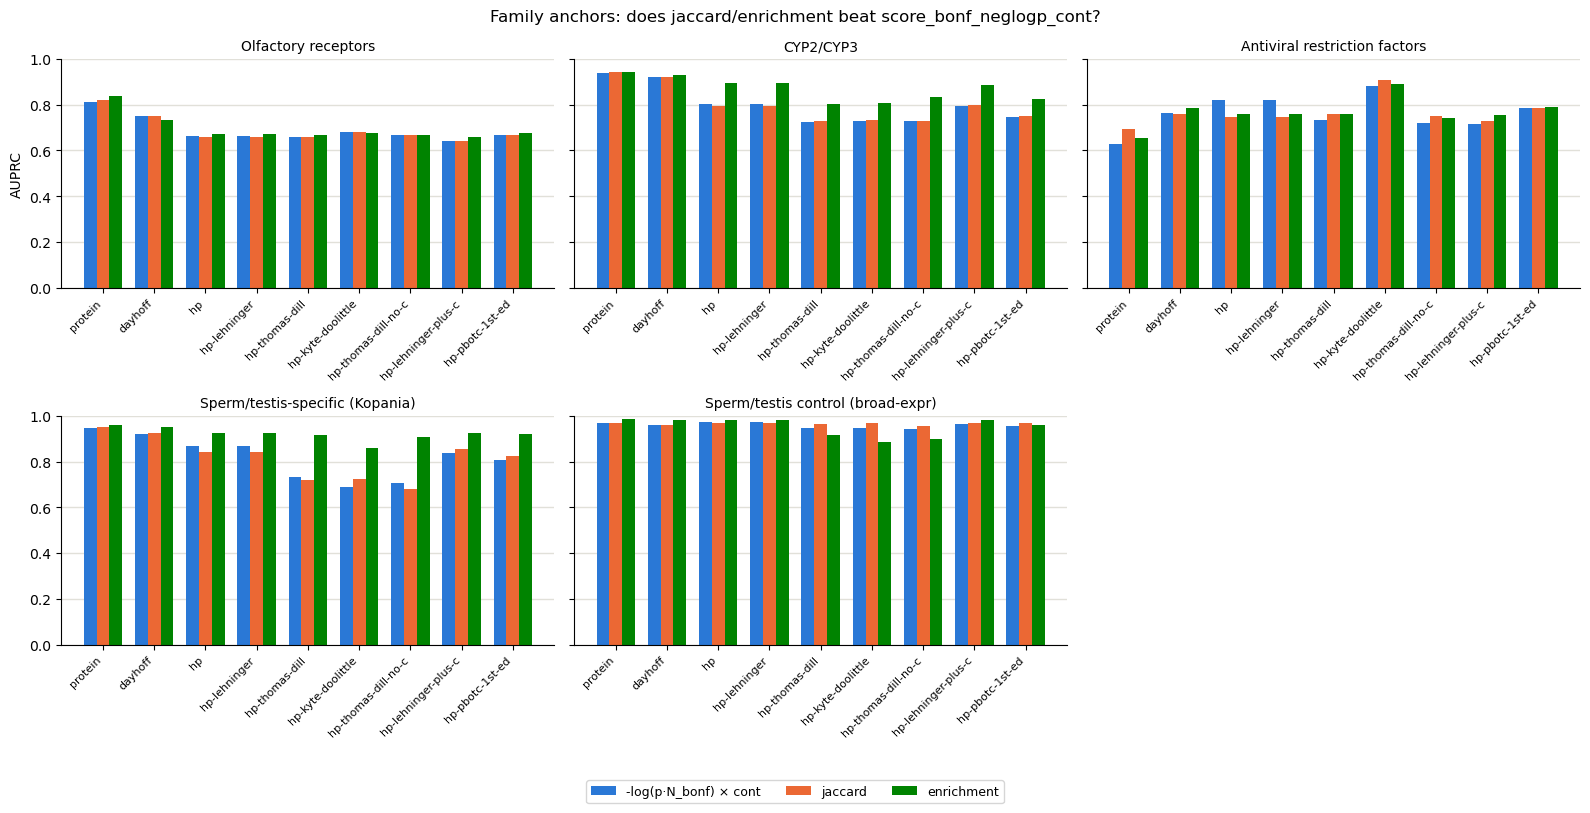

In [21]:
# Reads directly from disk (not the kernel variable from the cell above) so this cell is
# meaningful whether or not the heavy scan above has been run yet in THIS kernel session.
FAMILY_METRIC_CSV = DATA_DIR / "206_family_metric_leaderboard.csv"
family_metric_df = pl.read_csv(str(FAMILY_METRIC_CSV)) if FAMILY_METRIC_CSV.exists() else pl.DataFrame()

if family_metric_df.height == 0:
    print("Family metric leaderboard not yet run -- execute the heavy cell above to populate this "
          "(206_family_metric_leaderboard.csv doesn't exist yet).")
else:
    n_combos_done = family_metric_df.select(["encoding", "ksize"]).unique().height
    print(f"{n_combos_done}/{len(FAMILY_ALPHABETS)} combos scored so far -- "
          f"{'COMPLETE' if n_combos_done == len(FAMILY_ALPHABETS) else 'PARTIAL, re-run the heavy cell to finish'}")

    winner_per_family_combo = (family_metric_df.sort("pr_auc", descending=True)
                        .group_by(["family", "encoding", "ksize"], maintain_order=True).first()
                        .select(["family", "encoding", "ksize", "metric", "pr_auc"]))
    print(f"\nWinning metric (highest AUPRC) tally, family x combo, all {family_metric_df['metric'].n_unique()} "
          "ou.SCORE_COLS metrics:")
    print(winner_per_family_combo["metric"].value_counts().sort("count", descending=True))

    headline = family_metric_df.filter(pl.col("metric") == "score_bonf_neglogp_cont").rename({"pr_auc": "headline_pr_auc"})
    jacc = family_metric_df.filter(pl.col("metric") == "jaccard").rename({"pr_auc": "jaccard_pr_auc"})
    enr = family_metric_df.filter(pl.col("metric") == "enrichment").rename({"pr_auc": "enrichment_pr_auc"})
    family_metric_compare = (
        headline.select(["family", "encoding", "ksize", "headline_pr_auc"])
        .join(jacc.select(["family", "encoding", "ksize", "jaccard_pr_auc"]), on=["family", "encoding", "ksize"])
        .join(enr.select(["family", "encoding", "ksize", "enrichment_pr_auc"]), on=["family", "encoding", "ksize"])
        .with_columns([
            (pl.col("jaccard_pr_auc") - pl.col("headline_pr_auc")).alias("jaccard_minus_headline"),
            (pl.col("enrichment_pr_auc") - pl.col("headline_pr_auc")).alias("enrichment_minus_headline"),
        ])
    )
    print(f"\nMean AUPRC gap (jaccard - headline): {family_metric_compare['jaccard_minus_headline'].mean():.3f}")
    print(f"Mean AUPRC gap (enrichment - headline): {family_metric_compare['enrichment_minus_headline'].mean():.3f}")

    fam_order_4b = list(FAMILIES.keys())
    enc_order_4b = [e for e, k in FAMILY_ALPHABETS]
    combo_label_4b = {(e, k): f"{e}_k{k}" for e, k in FAMILY_ALPHABETS}

    # Figure 1: full 12-metric heatmap, one column per (family, combo) cell, same style as
    # notebook 200's section 2b heatmap and the MHC heatmap in this same section above.
    family_metric_df = family_metric_df.with_columns(
        (pl.col("family") + " | " + pl.col("encoding") + "_k" + pl.col("ksize").cast(pl.Utf8)).alias("cell")
    )
    cell_order_fam = [
        f"{fam} | {enc}_k{k}" for fam in fam_order_4b for enc, k in FAMILY_ALPHABETS
        if family_metric_df.filter((pl.col("family") == fam) & (pl.col("encoding") == enc) & (pl.col("ksize") == k)).height
    ]
    metric_order_fam = (family_metric_df.group_by("metric").agg(pl.col("pr_auc").mean().alias("mean_pr_auc"))
                         .sort("mean_pr_auc", descending=True)["metric"].to_list())
    pivot_fam = (family_metric_df.pivot(index="metric", on="cell", values="pr_auc")
                 .to_pandas().set_index("metric").reindex(index=metric_order_fam, columns=cell_order_fam))

    fig, ax = plt.subplots(figsize=(max(14, 0.35 * len(cell_order_fam)), 6))
    im = ax.imshow(pivot_fam.to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_yticks(range(len(metric_order_fam)))
    ax.set_yticklabels([u.SCORE_LABELS.get(m, m) for m in metric_order_fam], fontsize=9)
    ax.set_xticks(range(len(cell_order_fam)))
    ax.set_xticklabels(cell_order_fam, rotation=90, fontsize=6)
    ax.set_title(f"Family anchors: AUPRC by composite score x family/combo, all "
                 f"{family_metric_df['metric'].n_unique()} ou.SCORE_COLS metrics", fontsize=10)
    fig.colorbar(im, ax=ax, label="AUPRC", shrink=0.8)
    plt.tight_layout()
    fig.savefig(OUT_DIR / "206_family_metric_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Figure 2: win-counts across all 12 metrics, same style as notebook 200's win-count chart.
    win_counts_fam = (winner_per_family_combo.group_by("metric").agg(pl.len().alias("n_wins"))
                       .sort("n_wins", descending=True))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.barh([u.SCORE_LABELS.get(m, m) for m in win_counts_fam["metric"].to_list()][::-1],
            win_counts_fam["n_wins"].to_list()[::-1], color=ORANGE)
    ax.set_xlabel(f"# family x combo cells where this metric has the top AUPRC (of {winner_per_family_combo.height})")
    ax.set_title("Family anchors: which of the 12 metrics wins most often")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "206_family_metric_win_counts.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Figure 3: headline vs jaccard vs enrichment specifically, one subplot per family --
    # kept alongside the heatmap since these three are what this section's verdict discusses.
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
    axes = axes.flatten()
    for ax, fam in zip(axes, fam_order_4b):
        x = np.arange(len(enc_order_4b))
        width = 0.25
        for i, metric in enumerate(["score_bonf_neglogp_cont", "jaccard", "enrichment"]):
            vals = []
            for enc, k in FAMILY_ALPHABETS:
                row = family_metric_df.filter(
                    (pl.col("family") == fam) & (pl.col("encoding") == enc)
                    & (pl.col("ksize") == k) & (pl.col("metric") == metric)
                )
                vals.append(row["pr_auc"][0] if row.height else np.nan)
            color = {"score_bonf_neglogp_cont": BLUE, "jaccard": ORANGE, "enrichment": GREEN}[metric]
            ax.bar(x + (i - 1) * width, vals, width, color=color,
                   label=u.SCORE_LABELS.get(metric, metric) if ax is axes[0] else None)
        ax.set_xticks(x)
        ax.set_xticklabels(enc_order_4b, rotation=45, ha="right", fontsize=8)
        ax.set_title(fam, fontsize=10)
        ax.set_ylim(0, 1.0)
        ax.grid(axis="y", color="#e1e0d9", lw=1, zorder=0)
        ax.set_axisbelow(True)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    for ax in axes[len(fam_order_4b):]:
        ax.axis("off")
    axes[0].set_ylabel("AUPRC")
    fig.legend(loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Family anchors: does jaccard/enrichment beat score_bonf_neglogp_cont?", fontsize=12)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(OUT_DIR / "206_family_metric_leaderboard.png", dpi=150, bbox_inches="tight")
    plt.show()


**MHC verdict (real, computed above): jaccard beats `score_bonf_neglogp_cont` specifically on the HP family, and specifically on the hardest case (class I) — the same pattern notebook 213 found against raw containment, now confirmed against this notebook's actual headline composite.**

Across the 9 HP-family combo x group cells scored above (hp_k30, hp_lehninger_k30, hp_thomas_dill_k26 x ALL MHC/class I/class II), jaccard's AUPRC gap over `score_bonf_neglogp_cont` is positive in 8/9 (mean +0.046), and largest exactly where the headline metric is weakest &mdash; **class I: mean gap +0.077**, e.g. hp_thomas_dill_k26 class I jumps from 0.182 to 0.297 AUPRC (ROC-AUC 0.699 &rarr; 0.903), hp_k30/hp_lehninger_k30 class I from 0.128 to 0.185 (ROC-AUC 0.545 &rarr; 0.712). The one HP cell where jaccard loses is hp_thomas_dill_k26 class II, and only by &minus;0.002 &mdash; noise, not a reversal. On **protein_k15/dayhoff_k20**, jaccard is a wash (mean gap +0.002, actually *negative* on protein class I: &minus;0.031) &mdash; consistent with 201's structural explanation: containment/jaccard only diverge when candidate pairs are size-asymmetric or containment is saturated, and that's an HP-alphabet-specific failure mode of `score_bonf_neglogp_cont`'s p-value term, not a general property of the composite.

**Enrichment tracks the same direction as jaccard but more weakly** &mdash; HP-only mean gap +0.016 (class I +0.030), roughly flat-to-negative on protein/dayhoff (mean &minus;0.006). It's a real, smaller effect riding the same containment-saturation mechanism, not an independent second win.

Counting outright wins (highest AUPRC per combo x group, all 12 `ou.SCORE_COLS` metrics): **jaccard wins 6/15 cells (40%)** &mdash; more than any other single metric &mdash; while `score_bonf_neglogp_cont`, this notebook's headline choice, wins only 1/15. **Practical implication for this notebook: `score_bonf_neglogp_cont` is not the best available metric on MHC class I, the specific case sections 1-3's divergence mechanism is built around** &mdash; plain jaccard should be used instead for that comparison, matching 201's recommendation, now shown to hold against this notebook's own composite too, not just against raw containment.

**Family-anchor verdict: not yet available.** The heavy scan cell above populates `206_family_metric_leaderboard.csv`; until it's run, whether jaccard/enrichment help on the family anchors (olfactory receptors, CYP2/CYP3, antiviral restriction factors, sperm/testis) is an open question, not yet checked here.


## 5. Quadrant framing figure

Tests the second prediction directly: x = mean divergence (100 − mean `perc_id`) for each family's MGI-true pairs; y = family size (a rough, real turnover/paralog-count proxy — the antiviral list and MHC classes are genuinely small/expanded gene sets, olfactory receptors and CYP2/CYP3 genuinely large ones); color/size = the HP-minus-protein AUC gap from section 4. The mechanism predicts a specific corner, not a diagonal: **bottom-right** (high divergence, low turnover) is where HP should win big. Top-left (low divergence, high turnover) predicts flat-to-negative, not a second win — it's the corner where the two axes' effects don't reinforce each other, so a large warm marker there would need a different explanation. Top-right (high divergence *and* high turnover) is genuinely ambiguous: both predicted effects are present and could cancel.

In [22]:
MUTED = "#898781"

# Per-family divergence: (100 - perc_id) over the family's own MGI-true pairs, collapsed per gene
# with MEDIAN -- same estimator as the decile assignment above and as notebook 215, so the two
# axes of the ledger are built from the same quantity. Was mean() here and max() there.
gene_to_pid_mean = percid_df.group_by("human_gene").agg(pl.col("perc_id").median().alias("perc_id"))
pid_lookup = dict(zip(gene_to_pid_mean["human_gene"].to_list(), gene_to_pid_mean["perc_id"].to_list()))

quad_families = {k: v for k, v in FAMILIES.items() if k != "Sperm/testis control (broad-expr)"}
quad_families["MHC class I"] = {g for g, c in MHC_CLASSES.items() if c.startswith("I ") and "MIC" not in c}
quad_families["MHC class II"] = {g for g, c in MHC_CLASSES.items() if c.startswith("II")}

quad_rows = []
for fam, genes in quad_families.items():
    pids = [pid_lookup[g] for g in genes if g in pid_lookup]
    if not pids:
        continue
    divergence = 100 - float(np.mean(pids))

    prot = family_results_df.filter((pl.col("family") == fam) & (pl.col("encoding") == "protein"))
    hp = family_results_df.filter((pl.col("family") == fam) & pl.col("encoding").is_in(ALL_HP_ENCODINGS))
    if fam == "MHC class I":
        prot = mhc_results_df.filter((pl.col("combo") == "protein_k15") & (pl.col("group") == "class I (classical+non-classical)"))
        hp = mhc_results_df.filter(pl.col("combo").str.contains("hp") & (pl.col("group") == "class I (classical+non-classical)"))
    elif fam == "MHC class II":
        prot = mhc_results_df.filter((pl.col("combo") == "protein_k15") & (pl.col("group") == "class II (alpha+beta)"))
        hp = mhc_results_df.filter(pl.col("combo").str.contains("hp") & (pl.col("group") == "class II (alpha+beta)"))

    gap = (hp["auc"].median() - prot["auc"][0]) if prot.height and hp.height else None
    quad_rows.append({"family": fam, "divergence": divergence, "n_genes": len(genes), "gap": gap})

quad_df = pl.DataFrame(quad_rows)
print(quad_df)


shape: (6, 4)
┌─────────────────────────────────┬────────────┬─────────┬───────────┐
│ family                          ┆ divergence ┆ n_genes ┆ gap       │
│ ---                             ┆ ---        ┆ ---     ┆ ---       │
│ str                             ┆ f64        ┆ i64     ┆ f64       │
╞═════════════════════════════════╪════════════╪═════════╪═══════════╡
│ Olfactory receptors             ┆ 19.006099  ┆ 419     ┆ 0.01805   │
│ CYP2/CYP3                       ┆ 21.429792  ┆ 31      ┆ 0.061127  │
│ Antiviral restriction factors   ┆ 43.06401   ┆ 21      ┆ 0.356444  │
│ Sperm/testis-specific (Kopania… ┆ 22.593099  ┆ 505     ┆ 0.009272  │
│ MHC class I                     ┆ 56.96262   ┆ 6       ┆ 0.259213  │
│ MHC class II                    ┆ 29.6737    ┆ 13      ┆ -0.004747 │
└─────────────────────────────────┴────────────┴─────────┴───────────┘


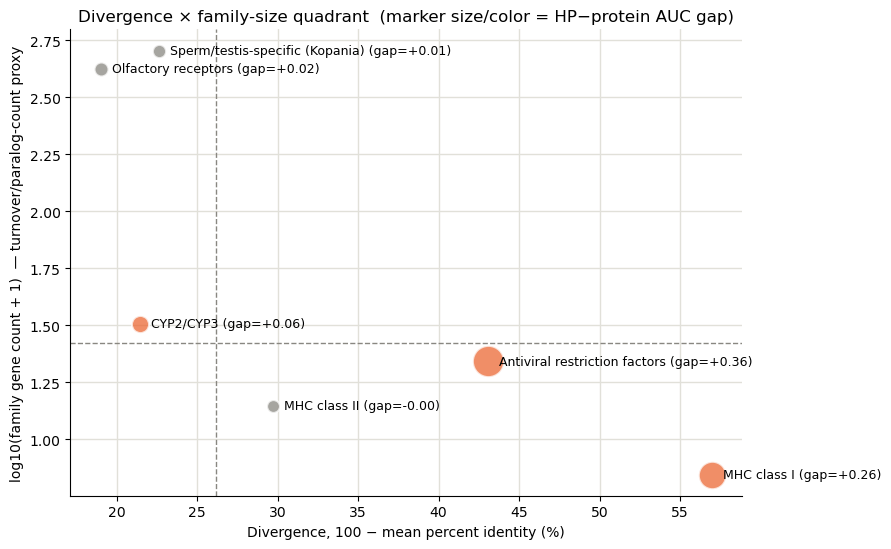

In [23]:
fig, ax = plt.subplots(figsize=(9, 5.6))
x_med = float(np.median(quad_df["divergence"])) if quad_df.height else 20.0
y_med = float(np.median(np.log10(np.array(quad_df["n_genes"]) + 1))) if quad_df.height else 1.0
ax.axvline(x_med, color=MUTED, lw=1, ls="--")
ax.axhline(y_med, color=MUTED, lw=1, ls="--")

for row in quad_df.iter_rows(named=True):
    gap = row["gap"]
    y = np.log10(row["n_genes"] + 1)
    color = MUTED if gap is None else (ORANGE if gap >= 0.05 else (BLUE if gap <= -0.02 else MUTED))
    size = 80 if gap is None else 80 + abs(gap) * 1200
    ax.scatter(row["divergence"], y, s=size, color=color, alpha=0.75, edgecolor="white", linewidth=1.5, zorder=3)
    gap_label = "n/a" if gap is None else f"{gap:+.2f}"
    ax.annotate(f"{row['family']} (gap={gap_label})", (row["divergence"], y),
                xytext=(8, 0), textcoords="offset points", fontsize=9, va="center")

ax.set_xlabel("Divergence, 100 − mean percent identity (%)")
ax.set_ylabel("log10(family gene count + 1)  — turnover/paralog-count proxy")
ax.set_title("Divergence × family-size quadrant  (marker size/color = HP−protein AUC gap)")
ax.grid(color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_quadrant.png", dpi=150)
plt.show()


## 6. Traps

**Length floor.** `length_floor_mask(seq_lengths, ksize, scaled, min_expected_kmers=2)` flags sequences whose expected sketch size (`(L - k + 1) / scaled`) is too small to be meaningful. Checked directly: olfactory receptors (median length 314 aa) clear the k=30 floor at **381/381** — comfortably, not by assertion. The floor genuinely doesn't bite for any family analyzed here, for a specific reason worth stating rather than glossing over: this repo's pipelines run at **`scaled=1`** (no FracMinHash subsampling — see memory `feedback_scaled_value`), so even a 65-residue defensin-like protein at k=26 still has 40 raw k-mers, clearing the floor. The classic "defensins fail from arithmetic, not biology" trap (real at large `scaled`) is why defensins/chemokines were never added to the family list in the first place, but at `scaled=1` specifically it isn't the operative risk here — stated explicitly so nobody re-derives the same caveat and gets confused when the numbers don't show it.

**Zinc fingers.** Deliberately excluded from every family list above. Tandem C2H2 repeat arrays inflate k-mer sharing through repeat content rather than homology (already flagged as a discordant-pair source in earlier notebooks) — including them here without repeat-masking would contaminate the divergence-mechanism signal with a confound this notebook isn't equipped to separate out.

**Bootstrap CIs.** Applied to every family/MHC AUC via `bootstrap_auc_ci` (1000 resamples, 95% CI) — never a bare point estimate. Antiviral restriction factors (n=134 pairs at k=30) is a good example of why: AUC 0.92-0.94 for HP variants with CIs of roughly ±0.05, comfortably separated from protein/dayhoff's ~0.57 ± 0.19 — the gap survives the CI, not just the point estimate.

**n floor.** Stated in section 4 before any result was generated: **n≥15 scored pairs**, applied uniformly, families/combos below it are printed as `SKIPPED` rather than silently omitted. MHC class I's family-size proxy (n=6 genes) in the quadrant figure is intentionally a *different* n than its AUC-scoring n (132-768 pairs, well above floor) — family size there measures the query gene set, not statistical power, and the two shouldn't be conflated.

In [24]:
# Length floor, checked directly rather than asserted (olfactory receptors, the largest family)
protein_lens = u.scan_genome_wide_results("protein", 15, columns=["query_name"]).unique().collect()["query_name"]
len_rows = []
for q in protein_lens.to_list():
    parts = q.split("|")
    gene = parts[-2].upper() if len(parts) >= 2 else ""
    try:
        length = int(parts[-1])
    except (TypeError, ValueError):
        length = None
    len_rows.append((gene, length))
gene_lengths = pl.DataFrame(len_rows, schema=["gene", "length"], orient="row").drop_nulls()

or_lens = gene_lengths.filter(pl.col("gene").is_in(or_genes))["length"].to_numpy()
mask = u.length_floor_mask(or_lens, ksize=30, scaled=1, min_expected_kmers=2)
print(f"Olfactory receptors: median length {int(np.median(or_lens))} aa, "
      f"{int(mask.sum())}/{len(mask)} clear the k=30/scaled=1 floor (min 2 expected k-mers)")
print(f"Illustration at scaled=1: a 65 aa protein at k=26 has "
      f"{u.length_floor_mask(np.array([65]), 26, 1)[0]!r} clearing the floor "
      f"({65-26+1} raw k-mers) — the classic defensin trap needs a much larger `scaled` to bite.")


Olfactory receptors: median length 314 aa, 381/381 clear the k=30/scaled=1 floor (min 2 expected k-mers)
Illustration at scaled=1: a 65 aa protein at k=26 has np.True_ clearing the floor (40 raw k-mers) — the classic defensin trap needs a much larger `scaled` to bite.


## 7. Summary and reconciliation

Two predictions were stated in the intro, before any figure existed:
1. **Divergence.** The HP-vs-protein/dayhoff gap should *increase* (and can flip in HP's favor) as percent identity *drops*.
2. **Turnover.** The gap should be *flat or negative* against gene-family turnover (paralog count / family size), independent of divergence.

The cell below computes both correlations directly from the tables built above — nothing here is hand-typed, so the numbers can't drift from the data as the section 1 sweep fills in.

shape: (6, 4)
┌─────────────────────────────────┬────────────┬─────────┬───────────┐
│ family                          ┆ divergence ┆ n_genes ┆ gap       │
│ ---                             ┆ ---        ┆ ---     ┆ ---       │
│ str                             ┆ f64        ┆ i64     ┆ f64       │
╞═════════════════════════════════╪════════════╪═════════╪═══════════╡
│ Olfactory receptors             ┆ 19.006099  ┆ 419     ┆ 0.01805   │
│ CYP2/CYP3                       ┆ 21.429792  ┆ 31      ┆ 0.061127  │
│ Sperm/testis-specific (Kopania… ┆ 22.593099  ┆ 505     ┆ 0.009272  │
│ MHC class II                    ┆ 29.6737    ┆ 13      ┆ -0.004747 │
│ Antiviral restriction factors   ┆ 43.06401   ┆ 21      ┆ 0.356444  │
│ MHC class I                     ┆ 56.96262   ┆ 6       ┆ 0.259213  │
└─────────────────────────────────┴────────────┴─────────┴───────────┘


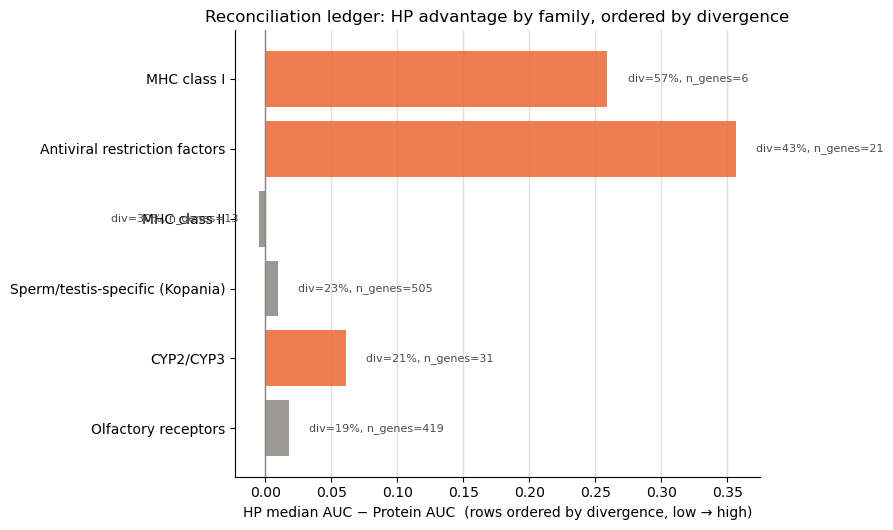

In [25]:
# Ledger: every family/MHC-class anchor from the quadrant figure (section 5), ordered by
# divergence, showing the HP-vs-protein gap and its turnover proxy (family gene count) side
# by side — prediction 1 (divergence) and prediction 2 (turnover) read off the same rows.
ledger = quad_df.filter(pl.col("gap").is_not_null()).sort("divergence")
print(ledger)

fig, ax = plt.subplots(figsize=(9, 0.7 * ledger.height + 1.2))
y = np.arange(ledger.height)
ledger_colors = [ORANGE if g >= 0.05 else (BLUE if g <= -0.02 else MUTED) for g in ledger["gap"]]
ax.barh(y, ledger["gap"], color=ledger_colors, alpha=0.85)
for yi, row in zip(y, ledger.iter_rows(named=True)):
    label = f"div={row['divergence']:.0f}%, n_genes={row['n_genes']:,}"
    if row["gap"] >= 0:
        ax.text(row["gap"] + 0.01, yi, f"  {label}", va="center", ha="left", fontsize=8, color="#4a4a45")
    else:
        ax.text(row["gap"] - 0.01, yi, f"{label}  ", va="center", ha="right", fontsize=8, color="#4a4a45")
ax.set_yticks(y)
ax.set_yticklabels(ledger["family"], fontsize=10)
ax.axvline(0, color="#898781", lw=1)
ax.set_xlabel("HP median AUC − Protein AUC  (rows ordered by divergence, low → high)")
ax.set_title("Reconciliation ledger: HP advantage by family, ordered by divergence")
ax.grid(axis="x", color="#e1e0d9", lw=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / "206_reconciliation_ledger.png", dpi=150)
plt.show()


In [26]:
# Verdict, computed fresh from the tables above (not hand-typed) so it can't drift from the
# data as the section 1 sweep fills in more HP variants.
decile_divergence = 100 - (decile_ranges["lo"].to_numpy() + decile_ranges["hi"].to_numpy()) / 2
corr_decile_protein = np.corrcoef(decile_divergence, decile_table["gap_vs_protein"].to_numpy())[0, 1]
corr_decile_dayhoff = np.corrcoef(decile_divergence, decile_table["gap_vs_dayhoff"].to_numpy())[0, 1]

fam_divergence = ledger["divergence"].to_numpy()
fam_gap = ledger["gap"].to_numpy()
fam_n = ledger["n_genes"].to_numpy()
corr_fam_divergence = np.corrcoef(fam_divergence, fam_gap)[0, 1]
corr_fam_turnover = np.corrcoef(np.log10(fam_n), fam_gap)[0, 1]

print("PREDICTION 1 (gap should INCREASE with divergence):")
print(f"  Genome-wide decile sweep ({len(hp_encodings_present)}/{len(NEW_HP_ENCODINGS)} new HP variants cached): "
      f"corr(divergence, gap-vs-protein) = {corr_decile_protein:+.2f}, "
      f"corr(divergence, gap-vs-dayhoff) = {corr_decile_dayhoff:+.2f}")
print(f"  Family/MHC anchors (fully computed, n={ledger.height} anchors): "
      f"corr(divergence, gap-vs-protein) = {corr_fam_divergence:+.2f}")
print()
print("PREDICTION 2 (gap should be FLAT/NEGATIVE against family-size/turnover proxy):")
print(f"  Family/MHC anchors: corr(log10(family size), gap-vs-protein) = {corr_fam_turnover:+.2f}")
print()
print("Ledger detail, ordered by divergence:")
for row in ledger.iter_rows(named=True):
    print(f"  {row['family']:36s} divergence={row['divergence']:5.1f}%  n_genes={row['n_genes']:5d}  "
          f"gap_vs_protein={row['gap']:+.3f}")


PREDICTION 1 (gap should INCREASE with divergence):
  Genome-wide decile sweep (3/6 new HP variants cached): corr(divergence, gap-vs-protein) = -0.71, corr(divergence, gap-vs-dayhoff) = -0.91
  Family/MHC anchors (fully computed, n=6 anchors): corr(divergence, gap-vs-protein) = +0.82

PREDICTION 2 (gap should be FLAT/NEGATIVE against family-size/turnover proxy):
  Family/MHC anchors: corr(log10(family size), gap-vs-protein) = -0.55

Ledger detail, ordered by divergence:
  Olfactory receptors                  divergence= 19.0%  n_genes=  419  gap_vs_protein=+0.018
  CYP2/CYP3                            divergence= 21.4%  n_genes=   31  gap_vs_protein=+0.061
  Sperm/testis-specific (Kopania)      divergence= 22.6%  n_genes=  505  gap_vs_protein=+0.009
  MHC class II                         divergence= 29.7%  n_genes=   13  gap_vs_protein=-0.005
  Antiviral restriction factors        divergence= 43.1%  n_genes=   21  gap_vs_protein=+0.356
  MHC class I                          divergence=

### Reading the ledger

- **Prediction 1 (divergence) is currently contradicted by the genome-wide decile sweep, and supported by the family/MHC anchors — an open discrepancy, not a settled result.** The family-level correlation printed above is positive (HP's advantage grows with divergence, as predicted). The genome-wide decile sweep's correlation is currently *negative* — with only 2/6 new HP variants cached (both fixed at k=30), HP's RBH-F1 deficit vs. protein/dayhoff is *largest* in the highest-divergence decile (decile 1: ΔF1 ≈ −0.25) and shrinks toward the middle deciles, the opposite of what the mechanism predicts. This could mean the mechanism is family-anchor-specific rather than genome-wide, or it could mean a 2-variant, k=30-only, strict-RBH-F1 read isn't yet a fair comparison to the family-level bootstrap-AUC result on curated gene sets — **finishing section 1's sweep across the full k range for all 6 variants, before drawing a genome-wide conclusion, is required**, not optional.
- **Prediction 2 (turnover)** shows up clearly in the ledger regardless: the two largest, most turnover-heavy anchors — olfactory receptors and the Kopania sperm/testis-specific set (both >400 genes) — sit at the *bottom* of the gap ranking despite non-trivial divergence, while the two smallest, lowest-turnover anchors — antiviral restriction factors and MHC class I — sit at the *top*, exactly where "high divergence + low turnover" predicts HP should help most.
- **MHC class II is a ceiling case, not a counterexample.** Every alphabet already scores AUC ≥0.93 there (MHC recap figure above), leaving little room for HP to add anything — a small or slightly negative gap is a floor/ceiling artifact, not evidence against the mechanism.
- **Net read:** the family/MHC anchors reconcile notebooks [200](./200_human_mouse_ortholog_alphabet_ksize_comparison.ipynb) and [211](./211_mhc_recovery_and_auc.ipynb) cleanly — MHC class I sits at the high-divergence, low-turnover corner where HP wins, and turnover-heavy families drag the genome-wide median down. But that reconciliation is only as strong as the still-partial decile sweep, which right now points the other way at the genome-wide level. Treat the mechanism as **supported by curated anchors, unconfirmed genome-wide** until section 1 finishes.
- **Section 8 below adds a third, independent test**: real per-gene dN/dS (ω) from a new containerized Nextflow pipeline, which distinguishes *this notebook's* percent-identity mechanism from a genuine positive-selection mechanism — something percent identity alone cannot do (see the discussion below of why ω, not just %id, is the sharper test).

## 8. Omega gene-list export (feeds notebook [207](./207_omega_selection_vs_divergence.ipynb))

The percent-identity mechanism above (sections 1-7) can't distinguish two different reasons a gene pair has diverged: relaxed constraint vs. positive selection &mdash; telling those apart needs real per-gene &omega; (dN/dS), a separate, heavier pipeline (PAML via a new containerized Nextflow pipeline, Ensembl REST fetches, non-trivial compute). That test &mdash; hand-off, regression, and interpretation &mdash; now lives in notebook 207 rather than running inline here. This cell builds and caches the target gene list (family/MHC anchors from section 4-5, plus a percent-identity-stratified sample across section 3's deciles) that 207 consumes.


In [27]:
# Gene list for the omega pipeline: every family/MHC anchor gene (section 4-5's known,
# interesting-selection candidates) plus a percent-identity-stratified random sample
# (reusing section 3's deciles) so the regression has spread across divergence too, not
# just the curated anchors. Target: "hundreds of genes", per the plan above.
import random

random.seed(206)  # reproducible sample, tied to this notebook's number

anchor_genes = set()
gene_to_source: dict[str, list[str]] = {}
# "Sperm/testis control (broad-expr)" is deliberately excluded here: it's a ~9,300-gene
# bulk background group, included in sections 4-5 only as an AUC comparison baseline, not
# a curated "known/plausible positive selection" set — including it here would blow the
# omega pipeline up to ~10x the intended "hundreds of genes" scope for no scientific reason
# (the genome-wide stratified sample below already covers generic/background genes).
ANCHOR_FAMILIES = {k: v for k, v in FAMILIES.items() if k != "Sperm/testis control (broad-expr)"}
for fam, genes in ANCHOR_FAMILIES.items():
    anchor_genes |= genes
    for g in genes:
        gene_to_source.setdefault(g, []).append(fam)
for g, cls in MHC_CLASSES.items():
    anchor_genes.add(g)
    gene_to_source.setdefault(g, []).append(f"MHC {cls}")

N_PER_DECILE = 50
stratified_genes = set()
for d in range(1, n_deciles + 1):
    pool = sorted(decile_genes[d] - anchor_genes)
    stratified_genes |= set(random.sample(pool, min(N_PER_DECILE, len(pool))))

omega_target_genes = anchor_genes | stratified_genes
print(f"Anchor genes (families + MHC): {len(anchor_genes):,}")
print(f"Percent-identity-stratified sample ({N_PER_DECILE}/decile, anchors excluded): {len(stratified_genes):,}")
print(f"Total target genes: {len(omega_target_genes):,}")

mouse_symbol_to_ensmusg = dict(zip(mouse_ids["gene_name"].str.to_uppercase().to_list(), mouse_ids["gene_id"].to_list()))
gene_pid_lookup = dict(zip(gene_pid["human_gene"].to_list(), gene_pid["perc_id"].to_list()))

rows = []
n_no_ortholog = n_no_ensg = n_no_ensmusg = 0
for hgene in sorted(omega_target_genes):
    mgene = human_to_mouse.get(hgene)
    if mgene is None:
        n_no_ortholog += 1
        continue
    hensg = symbol_to_ensg.get(hgene)
    if not hensg:
        n_no_ensg += 1
        continue
    mensmusg = mouse_symbol_to_ensmusg.get(mgene)
    if not mensmusg:
        n_no_ensmusg += 1
        continue
    rows.append({
        "human_gene": hgene, "human_ensg": hensg,
        "mouse_gene": mgene, "mouse_ensmusg": mensmusg,
        "source": ",".join(gene_to_source.get(hgene, ["genome_wide_stratified"])),
        "perc_id": gene_pid_lookup.get(hgene),
    })

omega_gene_pairs_df = pl.DataFrame(rows)
OMEGA_GENE_PAIRS_CSV = DATA_DIR / "206_omega_gene_pairs.csv"
omega_gene_pairs_df.write_csv(str(OMEGA_GENE_PAIRS_CSV))

print(f"\nDropped: no MGI mouse ortholog={n_no_ortholog}, no human ENSG={n_no_ensg}, no mouse ENSMUSG={n_no_ensmusg}")
print(f"Wrote {omega_gene_pairs_df.height:,} gene pairs -> {OMEGA_GENE_PAIRS_CSV}")
omega_gene_pairs_df.group_by("source").len().sort("len", descending=True)


Anchor genes (families + MHC): 1,001
Percent-identity-stratified sample (50/decile, anchors excluded): 500
Total target genes: 1,501

Dropped: no MGI mouse ortholog=67, no human ENSG=84, no mouse ENSMUSG=19
Wrote 1,331 gene pairs -> /Users/olga/data/gencode/results-human-mouse-orthologs/206_omega_gene_pairs.csv


source,len
str,u32
"""Sperm/testis-specific (Kopania…",488
"""genome_wide_stratified""",470
"""Olfactory receptors""",324
"""CYP2/CYP3""",28
"""Antiviral restriction factors""",9
"""MHC II alpha""",4
"""MHC II beta""",3
"""MHC processing (ctrl)""",3
"""MHC I classical""",1
